# 1. Project Setup & Data Loading
Load all required datasets including sales, inventory, products, stores, suppliers, replenishment, promotions, stockout events, and store layout.

In [1]:
import pandas as pd

In [2]:
base_path = r"C:\Users\gowth\Downloads\csv\\"

store_layout = pd.read_csv(base_path + "store_layout.csv")
sales = pd.read_csv(base_path + "sales_transactions.csv")
inventory = pd.read_csv(base_path + "inventory_snapshots.csv")
stockout = pd.read_csv(base_path + "stockout_events.csv")
forecast = pd.read_csv(base_path + "demand_forecasts.csv")
products = pd.read_csv(base_path + "products.csv")
stores = pd.read_csv(base_path + "stores.csv")
suppliers = pd.read_csv(base_path + "suppliers.csv")
replenishment = pd.read_csv(base_path + "replenishment_logs.csv")
promotions = pd.read_csv(base_path + "promotions.csv")

In [3]:
print("SALES NULLS:\n", sales.isnull().sum(), "\n")
print("INVENTORY NULLS:\n", inventory.isnull().sum(), "\n")
print("STOCKOUT NULLS:\n", stockout.isnull().sum(), "\n")
print("FORECAST NULLS:\n", forecast.isnull().sum(), "\n")
print("PRODUCTS NULLS:\n", products.isnull().sum(), "\n")
print("STORES NULLS:\n", stores.isnull().sum(), "\n")
print("SUPPLIERS NULLS:\n", suppliers.isnull().sum(), "\n")
print("REPLENISHMENT NULLS:\n", replenishment.isnull().sum(), "\n")
print("PROMOTIONS NULLS:\n", promotions.isnull().sum(), "\n")
print("STORE LAYOUT NULLS:\n", store_layout.isnull().sum(), "\n")

SALES NULLS:
 transaction_id              0
store_id                    0
sku_id                      0
sale_date                   0
units_sold                  0
unit_price_actual           0
revenue                     0
is_promoted                 0
promotion_id         25424557
dtype: int64 

INVENTORY NULLS:
 snapshot_id                  0
store_id                     0
sku_id                       0
snapshot_date                0
snapshot_time                0
units_on_hand                0
units_in_backroom            0
days_of_supply               0
expiry_nearest_date    2451002
dtype: int64 

STOCKOUT NULLS:
 stockout_id                  0
store_id                     0
sku_id                       0
stockout_date                0
restock_date              2682
duration_days                0
estimated_lost_units         0
estimated_lost_revenue       0
root_cause                   0
dtype: int64 

FORECAST NULLS:
 forecast_id        0
store_id           0
sku_id             

In [4]:
inventory.head(10)

,snapshot_id,store_id,sku_id,snapshot_date,snapshot_time,units_on_hand,units_in_backroom,days_of_supply,expiry_nearest_date
0,SNAP-S0001-P01049-0001,S0001,P01049,2024-01-01,08:00:00,413,0,15.59,NaN
1,SNAP-S0001-P01049-0002,S0001,P01049,2024-01-08,08:00:00,415,250,21.93,NaN
2,SNAP-S0001-P01049-0003,S0001,P01049,2024-01-15,08:00:00,413,69,21.83,NaN
3,SNAP-S0001-P01049-0004,S0001,P01049,2024-01-22,08:00:00,422,302,22.30,NaN
4,SNAP-S0001-P01049-0005,S0001,P01049,2024-01-29,08:00:00,421,137,22.25,NaN
5,SNAP-S0001-P01049-0006,S0001,P01049,2024-02-05,08:00:00,421,403,23.03,NaN
6,SNAP-S0001-P01049-0007,S0001,P01049,2024-02-12,08:00:00,421,255,23.03,NaN
7,SNAP-S0001-P01049-0008,S0001,P01049,2024-02-19,08:00:00,416,112,22.76,NaN
8,SNAP-S0001-P01049-0009,S0001,P01049,2024-02-26,08:00:00,424,369,23.20,NaN
9,SNAP-S0001-P01049-0010,S0001,P01049,2024-03-04,08:00:00,413,205,20.88,NaN


In [5]:
replenishment.head(10)

,replenishment_id,store_id,sku_id,replenishment_date,trigger_type,units_ordered,units_received,order_date,receive_date,lead_time_actual,replenishment_cost,associate_id
0,REP-S0001-P01049-0001,S0001,P01049,2024-01-02,Reorder Point,436,390,2024-01-01,2024-01-02,1,5327.40,EMP02056
1,REP-S0001-P01049-0002,S0001,P01049,2024-01-19,Reorder Point,436,379,2024-01-18,2024-01-19,1,5177.14,EMP02867
2,REP-S0001-P01049-0003,S0001,P01049,2024-02-05,Reorder Point,436,411,2024-02-04,2024-02-05,1,5614.26,EMP03836
3,REP-S0001-P01049-0004,S0001,P01049,2024-02-25,Reorder Point,436,413,2024-02-24,2024-02-25,1,5641.58,EMP02913
4,REP-S0001-P01049-0005,S0001,P01049,2024-03-14,Reorder Point,436,398,2024-03-13,2024-03-14,1,5436.68,EMP02809
5,REP-S0001-P01049-0006,S0001,P01049,2024-03-27,Reorder Point,436,370,2024-03-26,2024-03-27,1,5054.20,EMP04578
6,REP-S0001-P01049-0007,S0001,P01049,2024-04-12,Reorder Point,436,400,2024-04-11,2024-04-12,1,5464.00,EMP01652
7,REP-S0001-P01049-0008,S0001,P01049,2024-04-20,Reorder Point,436,431,2024-04-19,2024-04-20,1,5887.46,EMP01906
8,REP-S0001-P01049-0009,S0001,P01049,2024-04-30,Reorder Point,436,434,2024-04-29,2024-04-30,1,5928.44,EMP03984
9,REP-S0001-P01049-0010,S0001,P01049,2024-05-18,Reorder Point,436,394,2024-05-17,2024-05-18,1,5382.04,EMP02387


In [6]:
datasets = {
    "sales": sales,
    "inventory": inventory,
    "stockout": stockout,
    "forecast": forecast,
    "products": products,
    "stores": stores,
    "suppliers": suppliers,
    "replenishment": replenishment,
    "promotions": promotions,
    "store_layout": store_layout
}

In [7]:
sales.tail(10)

,transaction_id,store_id,sku_id,sale_date,units_sold,unit_price_actual,revenue,is_promoted,promotion_id
25969096,TX-S0478-P00131-20251222-0552,S0478,P00131,2025-12-22,14,29.58,414.12,False,NaN
25969097,TX-S0478-P00131-20251223-0553,S0478,P00131,2025-12-23,15,29.58,443.70,False,NaN
25969098,TX-S0478-P00131-20251224-0554,S0478,P00131,2025-12-24,21,29.58,621.18,False,NaN
25969099,TX-S0478-P00131-20251225-0555,S0478,P00131,2025-12-25,13,29.58,384.54,False,NaN
25969100,TX-S0478-P00131-20251226-0556,S0478,P00131,2025-12-26,18,29.58,532.44,False,NaN
25969101,TX-S0478-P00131-20251227-0557,S0478,P00131,2025-12-27,19,29.58,562.02,False,NaN
25969102,TX-S0478-P00131-20251228-0558,S0478,P00131,2025-12-28,26,29.58,769.08,False,NaN
25969103,TX-S0478-P00131-20251229-0559,S0478,P00131,2025-12-29,14,29.58,414.12,False,NaN
25969104,TX-S0478-P00131-20251230-0560,S0478,P00131,2025-12-30,15,29.58,443.70,False,NaN
25969105,TX-S0478-P00131-20251231-0561,S0478,P00131,2025-12-31,19,29.58,562.02,False,NaN


In [8]:
sales.head(10)

,transaction_id,store_id,sku_id,sale_date,units_sold,unit_price_actual,revenue,is_promoted,promotion_id
0,TX-S0001-P01049-20240101-0001,S0001,P01049,2024-01-01,22,36.81,809.82,False,NaN
1,TX-S0001-P01049-20240102-0002,S0001,P01049,2024-01-02,10,36.81,368.10,False,NaN
2,TX-S0001-P01049-20240103-0003,S0001,P01049,2024-01-03,18,36.81,662.58,False,NaN
3,TX-S0001-P01049-20240104-0004,S0001,P01049,2024-01-04,20,36.81,736.20,False,NaN
4,TX-S0001-P01049-20240105-0005,S0001,P01049,2024-01-05,24,36.81,883.44,False,NaN
5,TX-S0001-P01049-20240106-0006,S0001,P01049,2024-01-06,28,36.81,1030.68,False,NaN
6,TX-S0001-P01049-20240107-0007,S0001,P01049,2024-01-07,18,36.81,662.58,False,NaN
7,TX-S0001-P01049-20240108-0008,S0001,P01049,2024-01-08,20,36.81,736.20,False,NaN
8,TX-S0001-P01049-20240109-0009,S0001,P01049,2024-01-09,19,36.81,699.39,False,NaN
9,TX-S0001-P01049-20240110-0010,S0001,P01049,2024-01-10,32,36.81,1177.92,False,NaN


# 2. Data Cleaning & Date Conversion
Clean missing values, convert date columns, and prepare raw tables for analysis.

In [9]:
for name, df in datasets.items():
    for col in df.columns:
        # skip logical date columns that should remain null
        if col == 'expiry_nearest_date':
            continue

        # promotions.store_id null means all stores
        if name == 'promotions' and col == 'store_id':
            continue

        # stockout.restock_date null means still out of stock
        if name == 'stockout' and col == 'restock_date':
            continue

        # fill numeric columns with 0
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(0)


sales['promotion_id'] = sales['promotion_id'].fillna('NO_PROMO')
stockout['still_out_of_stock'] = stockout['restock_date'].isna().astype(int)


In [10]:
print("SALES NULLS:\n", sales.isnull().sum(), "\n")
print("INVENTORY NULLS:\n", inventory.isnull().sum(), "\n")
print("STOCKOUT NULLS:\n", stockout.isnull().sum(), "\n")
print("FORECAST NULLS:\n", forecast.isnull().sum(), "\n")
print("PRODUCTS NULLS:\n", products.isnull().sum(), "\n")
print("STORES NULLS:\n", stores.isnull().sum(), "\n")
print("SUPPLIERS NULLS:\n", suppliers.isnull().sum(), "\n")
print("REPLENISHMENT NULLS:\n", replenishment.isnull().sum(), "\n")
print("PROMOTIONS NULLS:\n", promotions.isnull().sum(), "\n")
print("STORE LAYOUT NULLS:\n", store_layout.isnull().sum(), "\n")

SALES NULLS:
 transaction_id       0
store_id             0
sku_id               0
sale_date            0
units_sold           0
unit_price_actual    0
revenue              0
is_promoted          0
promotion_id         0
dtype: int64 

INVENTORY NULLS:
 snapshot_id                  0
store_id                     0
sku_id                       0
snapshot_date                0
snapshot_time                0
units_on_hand                0
units_in_backroom            0
days_of_supply               0
expiry_nearest_date    2451002
dtype: int64 

STOCKOUT NULLS:
 stockout_id                  0
store_id                     0
sku_id                       0
stockout_date                0
restock_date              2682
duration_days                0
estimated_lost_units         0
estimated_lost_revenue       0
root_cause                   0
still_out_of_stock           0
dtype: int64 

FORECAST NULLS:
 forecast_id        0
store_id           0
sku_id             0
forecast_date      0
forecast_

In [11]:
stockout.columns


Index(['stockout_id', 'store_id', 'sku_id', 'stockout_date', 'restock_date',
       'duration_days', 'estimated_lost_units', 'estimated_lost_revenue',
       'root_cause', 'still_out_of_stock'],
      dtype='object')

In [12]:
stockout.head

<bound method NDFrame.head of                  stockout_id store_id  sku_id stockout_date restock_date  \
0       SO-S0001-P01023-0001    S0001  P01023    2024-01-15   2024-01-17   
1       SO-S0001-P01023-0002    S0001  P01023    2024-03-10   2024-03-17   
2       SO-S0001-P01023-0003    S0001  P01023    2024-04-12   2024-04-15   
3       SO-S0001-P01023-0004    S0001  P01023    2024-05-12   2024-05-17   
4       SO-S0001-P01023-0005    S0001  P01023    2024-06-08   2024-06-18   
...                      ...      ...     ...           ...          ...   
313594  SO-S0478-P00131-0039    S0478  P00131    2025-11-01   2025-11-02   
313595  SO-S0478-P00131-0040    S0478  P00131    2025-11-15   2025-11-26   
313596  SO-S0478-P00131-0041    S0478  P00131    2025-12-06   2025-12-07   
313597  SO-S0478-P00131-0042    S0478  P00131    2025-12-10   2025-12-19   
313598  SO-S0478-P00131-0043    S0478  P00131    2025-12-28   2025-12-29   

        duration_days  estimated_lost_units  estimated_lo

In [13]:
promotions['store_id'] = promotions['store_id'].fillna('ALL')

In [14]:
sales['sale_date'] = pd.to_datetime(sales['sale_date'], errors='coerce')

inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'], errors='coerce')
inventory['expiry_nearest_date'] = pd.to_datetime(inventory['expiry_nearest_date'], errors='coerce')

stockout['stockout_date'] = pd.to_datetime(stockout['stockout_date'], errors='coerce')
stockout['restock_date'] = pd.to_datetime(stockout['restock_date'], errors='coerce')

forecast['forecast_date'] = pd.to_datetime(forecast['forecast_date'], errors='coerce')
forecast['created_at'] = pd.to_datetime(forecast['created_at'], errors='coerce')

replenishment['replenishment_date'] = pd.to_datetime(replenishment['replenishment_date'], errors='coerce')
replenishment['order_date'] = pd.to_datetime(replenishment['order_date'], errors='coerce')
replenishment['receive_date'] = pd.to_datetime(replenishment['receive_date'], errors='coerce')

promotions['start_date'] = pd.to_datetime(promotions['start_date'], errors='coerce')
promotions['end_date'] = pd.to_datetime(promotions['end_date'], errors='coerce')

# 3. Expiry Date & Perishable Product Handling
Handle expiry dates for perishable products and estimate missing expiry information using shelf-life and SKU-level patterns.

In [15]:
inventory = inventory.merge(
    products[['sku_id', 'is_perishable', 'shelf_life_days']],
    on='sku_id',
    how='left'
)

In [16]:
inventory.loc[inventory['is_perishable'] == 0, 'expiry_nearest_date'] = pd.NaT

In [17]:
inventory['observed_days_to_expiry'] = (
    inventory['expiry_nearest_date'] - inventory['snapshot_date']
).dt.days

In [18]:
sku_expiry_pattern = (
    inventory[
        (inventory['is_perishable'] == 1) &
        (inventory['observed_days_to_expiry'].notna())
    ]
    .groupby('sku_id')['observed_days_to_expiry']
    .median()
)

inventory['sku_median_days_to_expiry'] = inventory['sku_id'].map(sku_expiry_pattern)

In [19]:
global_median_days_to_expiry = inventory.loc[
    (inventory['is_perishable'] == 1) &
    (inventory['observed_days_to_expiry'].notna()),
    'observed_days_to_expiry'
].median()

In [20]:
inventory['final_days_to_expiry'] = inventory['observed_days_to_expiry']

In [21]:
inventory['final_days_to_expiry'] = inventory['final_days_to_expiry'].fillna(
    inventory['sku_median_days_to_expiry']
)

inventory['final_days_to_expiry'] = inventory['final_days_to_expiry'].fillna(
    inventory['shelf_life_days']
)

inventory.loc[inventory['is_perishable'] == 1, 'final_days_to_expiry'] = (
    inventory.loc[inventory['is_perishable'] == 1, 'final_days_to_expiry']
    .fillna(global_median_days_to_expiry)
)

In [22]:
inventory['expiry_nearest_date_filled'] = inventory['expiry_nearest_date']

mask = (
    (inventory['is_perishable'] == 1) &
    (inventory['expiry_nearest_date_filled'].isna()) &
    (inventory['final_days_to_expiry'].notna())
)

inventory.loc[mask, 'expiry_nearest_date_filled'] = (
    inventory.loc[mask, 'snapshot_date'] +
    pd.to_timedelta(inventory.loc[mask, 'final_days_to_expiry'], unit='D')
)

In [23]:
inventory['final_days_to_expiry'] = (
    inventory['expiry_nearest_date_filled'] - inventory['snapshot_date']
).dt.days

In [24]:
inventory.tail

<bound method NDFrame.tail of                     snapshot_id store_id  sku_id snapshot_date snapshot_time  \
0        SNAP-S0001-P01049-0001    S0001  P01049    2024-01-01      08:00:00   
1        SNAP-S0001-P01049-0002    S0001  P01049    2024-01-08      08:00:00   
2        SNAP-S0001-P01049-0003    S0001  P01049    2024-01-15      08:00:00   
3        SNAP-S0001-P01049-0004    S0001  P01049    2024-01-22      08:00:00   
4        SNAP-S0001-P01049-0005    S0001  P01049    2024-01-29      08:00:00   
...                         ...      ...     ...           ...           ...   
4015195  SNAP-S0478-P00131-0101    S0478  P00131    2025-12-01      08:00:00   
4015196  SNAP-S0478-P00131-0102    S0478  P00131    2025-12-08      08:00:00   
4015197  SNAP-S0478-P00131-0103    S0478  P00131    2025-12-15      08:00:00   
4015198  SNAP-S0478-P00131-0104    S0478  P00131    2025-12-22      08:00:00   
4015199  SNAP-S0478-P00131-0105    S0478  P00131    2025-12-29      08:00:00   

         

In [25]:
inventory[['expiry_nearest_date', 'observed_days_to_expiry']].isna().mean()

expiry_nearest_date        0.610431
observed_days_to_expiry    0.610431
dtype: float64

In [26]:
print("SALES NULLS:\n", sales.isnull().sum(), "\n")
print("INVENTORY NULLS:\n", inventory.isnull().sum(), "\n")
print("STOCKOUT NULLS:\n", stockout.isnull().sum(), "\n")
print("FORECAST NULLS:\n", forecast.isnull().sum(), "\n")
print("PRODUCTS NULLS:\n", products.isnull().sum(), "\n")
print("STORES NULLS:\n", stores.isnull().sum(), "\n")
print("SUPPLIERS NULLS:\n", suppliers.isnull().sum(), "\n")
print("REPLENISHMENT NULLS:\n", replenishment.isnull().sum(), "\n")
print("PROMOTIONS NULLS:\n", promotions.isnull().sum(), "\n")
print("STORE LAYOUT NULLS:\n", store_layout.isnull().sum(), "\n")

SALES NULLS:
 transaction_id       0
store_id             0
sku_id               0
sale_date            0
units_sold           0
unit_price_actual    0
revenue              0
is_promoted          0
promotion_id         0
dtype: int64 

INVENTORY NULLS:
 snapshot_id                         0
store_id                            0
sku_id                              0
snapshot_date                       0
snapshot_time                       0
units_on_hand                       0
units_in_backroom                   0
days_of_supply                      0
expiry_nearest_date           2451002
is_perishable                       0
shelf_life_days                     0
observed_days_to_expiry       2451002
sku_median_days_to_expiry     2368590
final_days_to_expiry          2368590
expiry_nearest_date_filled    2368590
dtype: int64 

STOCKOUT NULLS:
 stockout_id                  0
store_id                     0
sku_id                       0
stockout_date                0
restock_date        

# 4. Phantom Inventory Detection — Historical Logic
#Detect phantom inventory by comparing expected inventory movement against actual shelf stock during stockout events.

In [27]:
phantom_causes = ['Shrinkage', 'Manual error']

stockout['phantom_inventory_label'] = (
    stockout['root_cause'].isin(phantom_causes)
).astype(int)

In [28]:
stockout[['root_cause',  'phantom_inventory_label']].head(20)

,root_cause,phantom_inventory_label
0,Demand spike,0
1,Manual error,1
2,Shrinkage,1
3,Supplier delay,0
4,Manual error,1
5,Manual error,1
6,Supplier delay,0
7,Demand spike,0
8,Manual error,1
9,Shrinkage,1


In [29]:
stockout_sorted = stockout.sort_values(
    ['stockout_date', 'store_id', 'sku_id']
).reset_index(drop=True)

inventory_sorted = inventory.sort_values(
    ['snapshot_date', 'store_id', 'sku_id']
).reset_index(drop=True)

stockout_sorted['stockout_date'] = pd.to_datetime(stockout_sorted['stockout_date'])
inventory_sorted['snapshot_date'] = pd.to_datetime(inventory_sorted['snapshot_date'])

stockout_with_inventory = pd.merge_asof(
    stockout_sorted,
    inventory_sorted[
        ['store_id', 'sku_id', 'snapshot_date', 'units_on_hand', 'units_in_backroom']
    ],
    left_on='stockout_date',
    right_on='snapshot_date',
    by=['store_id', 'sku_id'],
    direction='backward'
)

In [30]:
stockout_with_inventory['prev_total_stock'] = (
    stockout_with_inventory['units_on_hand'] +
    stockout_with_inventory['units_in_backroom']
)

In [31]:
stockout_with_inventory[
    ['store_id', 'sku_id', 'stockout_date', 'snapshot_date',
     'units_on_hand', 'units_in_backroom', 'prev_total_stock']
].head(10)

,store_id,sku_id,stockout_date,snapshot_date,units_on_hand,units_in_backroom,prev_total_stock
0,S0367,P00496,2024-01-06,2024-01-01,79,0,79
1,S0023,P00496,2024-01-07,2024-01-01,266,0,266
2,S0098,P00496,2024-01-07,2024-01-01,248,0,248
3,S0177,P00496,2024-01-07,2024-01-01,146,0,146
4,S0217,P00496,2024-01-07,2024-01-01,188,0,188
5,S0234,P00496,2024-01-07,2024-01-01,167,0,167
6,S0263,P00496,2024-01-07,2024-01-01,135,0,135
7,S0303,P00053,2024-01-07,2024-01-01,137,0,137
8,S0375,P00496,2024-01-07,2024-01-01,237,0,237
9,S0441,P00496,2024-01-07,2024-01-01,110,0,110


In [32]:
sales['sale_date'] = pd.to_datetime(sales['sale_date'])

sales_daily = (
    sales.groupby(['store_id', 'sku_id', 'sale_date'], as_index=False)['units_sold']
    .sum()
    .sort_values(['sale_date', 'store_id', 'sku_id'])
    .reset_index(drop=True)
)

In [33]:
sales_daily['cum_sales'] = (
    sales_daily.groupby(['store_id', 'sku_id'])['units_sold']
    .cumsum()
)

In [34]:

stockout_with_inventory = stockout_with_inventory.reset_index(drop=True)
stockout_with_inventory['row_id'] = stockout_with_inventory.index

stockout_with_inventory = stockout_with_inventory.sort_values(
    ['stockout_date', 'store_id', 'sku_id']
).reset_index(drop=True)

In [35]:
sales_at_stockout = pd.merge_asof(
    stockout_with_inventory[['row_id', 'store_id', 'sku_id', 'stockout_date']].sort_values(
        ['stockout_date', 'store_id', 'sku_id']
    ),
    sales_daily[['store_id', 'sku_id', 'sale_date', 'cum_sales']].sort_values(
        ['sale_date', 'store_id', 'sku_id']
    ),
    left_on='stockout_date',
    right_on='sale_date',
    by=['store_id', 'sku_id'],
    direction='backward'
)

In [36]:
sales_at_snapshot = pd.merge_asof(
    stockout_with_inventory[['row_id', 'store_id', 'sku_id', 'snapshot_date']].sort_values(
        ['snapshot_date', 'store_id', 'sku_id']
    ),
    sales_daily[['store_id', 'sku_id', 'sale_date', 'cum_sales']].sort_values(
        ['sale_date', 'store_id', 'sku_id']
    ),
    left_on='snapshot_date',
    right_on='sale_date',
    by=['store_id', 'sku_id'],
    direction='backward'
)

In [37]:
sales_at_stockout = sales_at_stockout[['row_id', 'cum_sales']].rename(
    columns={'cum_sales': 'cum_sales_stockout'}
)

sales_at_snapshot = sales_at_snapshot[['row_id', 'cum_sales']].rename(
    columns={'cum_sales': 'cum_sales_snapshot'}
)

stockout_with_inventory = stockout_with_inventory.merge(
    sales_at_stockout,
    on='row_id',
    how='left'
)

stockout_with_inventory = stockout_with_inventory.merge(
    sales_at_snapshot,
    on='row_id',
    how='left'
)

stockout_with_inventory['cum_sales_stockout'] = stockout_with_inventory['cum_sales_stockout'].fillna(0)
stockout_with_inventory['cum_sales_snapshot'] = stockout_with_inventory['cum_sales_snapshot'].fillna(0)

stockout_with_inventory['sales_between'] = (
    stockout_with_inventory['cum_sales_stockout'] -
    stockout_with_inventory['cum_sales_snapshot']
)

In [38]:
stockout_with_inventory[
    ['store_id', 'sku_id', 'snapshot_date', 'stockout_date',
     'prev_total_stock', 'sales_between']
].head(10)

,store_id,sku_id,snapshot_date,stockout_date,prev_total_stock,sales_between
0,S0367,P00496,2024-01-01,2024-01-06,79,79
1,S0023,P00496,2024-01-01,2024-01-07,266,252
2,S0098,P00496,2024-01-01,2024-01-07,248,240
3,S0177,P00496,2024-01-01,2024-01-07,146,146
4,S0217,P00496,2024-01-01,2024-01-07,188,188
5,S0234,P00496,2024-01-01,2024-01-07,167,166
6,S0263,P00496,2024-01-01,2024-01-07,135,131
7,S0303,P00053,2024-01-01,2024-01-07,137,137
8,S0375,P00496,2024-01-01,2024-01-07,237,237
9,S0441,P00496,2024-01-01,2024-01-07,110,109


In [39]:
replenishment['receive_date'] = pd.to_datetime(replenishment['receive_date'])

received_daily = (
    replenishment.groupby(['store_id', 'sku_id', 'receive_date'], as_index=False)['units_received']
    .sum()
    .sort_values(['receive_date', 'store_id', 'sku_id'])
    .reset_index(drop=True)
)

In [40]:
received_daily['cum_received'] = (
    received_daily.groupby(['store_id', 'sku_id'])['units_received']
    .cumsum()
)

In [41]:
received_at_stockout = pd.merge_asof(
    stockout_with_inventory[['row_id', 'store_id', 'sku_id', 'stockout_date']].sort_values(
        ['stockout_date', 'store_id', 'sku_id']
    ),
    received_daily[['store_id', 'sku_id', 'receive_date', 'cum_received']].sort_values(
        ['receive_date', 'store_id', 'sku_id']
    ),
    left_on='stockout_date',
    right_on='receive_date',
    by=['store_id', 'sku_id'],
    direction='backward'
)

In [42]:
received_at_snapshot = pd.merge_asof(
    stockout_with_inventory[['row_id', 'store_id', 'sku_id', 'snapshot_date']].sort_values(
        ['snapshot_date', 'store_id', 'sku_id']
    ),
    received_daily[['store_id', 'sku_id', 'receive_date', 'cum_received']].sort_values(
        ['receive_date', 'store_id', 'sku_id']
    ),
    left_on='snapshot_date',
    right_on='receive_date',
    by=['store_id', 'sku_id'],
    direction='backward'
)

In [43]:
received_at_stockout = received_at_stockout[['row_id', 'cum_received']].rename(
    columns={'cum_received': 'cum_received_stockout'}
)

received_at_snapshot = received_at_snapshot[['row_id', 'cum_received']].rename(
    columns={'cum_received': 'cum_received_snapshot'}
)

stockout_with_inventory = stockout_with_inventory.merge(
    received_at_stockout,
    on='row_id',
    how='left'
)

stockout_with_inventory = stockout_with_inventory.merge(
    received_at_snapshot,
    on='row_id',
    how='left'
)

stockout_with_inventory['cum_received_stockout'] = stockout_with_inventory['cum_received_stockout'].fillna(0)
stockout_with_inventory['cum_received_snapshot'] = stockout_with_inventory['cum_received_snapshot'].fillna(0)

stockout_with_inventory['received_between'] = (
    stockout_with_inventory['cum_received_stockout'] -
    stockout_with_inventory['cum_received_snapshot']
)

In [44]:
stockout_with_inventory[
    ['store_id', 'sku_id', 'snapshot_date', 'stockout_date',
     'prev_total_stock', 'sales_between', 'received_between']
].head(10)

,store_id,sku_id,snapshot_date,stockout_date,prev_total_stock,sales_between,received_between
0,S0367,P00496,2024-01-01,2024-01-06,79,79,0.0
1,S0023,P00496,2024-01-01,2024-01-07,266,252,0.0
2,S0098,P00496,2024-01-01,2024-01-07,248,240,0.0
3,S0177,P00496,2024-01-01,2024-01-07,146,146,0.0
4,S0217,P00496,2024-01-01,2024-01-07,188,188,0.0
5,S0234,P00496,2024-01-01,2024-01-07,167,166,0.0
6,S0263,P00496,2024-01-01,2024-01-07,135,131,0.0
7,S0303,P00053,2024-01-01,2024-01-07,137,137,0.0
8,S0375,P00496,2024-01-01,2024-01-07,237,237,0.0
9,S0441,P00496,2024-01-01,2024-01-07,110,109,0.0


In [45]:
stockout_with_inventory['expected_remaining'] = (
    stockout_with_inventory['prev_total_stock'] +
    stockout_with_inventory['received_between'] -
    stockout_with_inventory['sales_between']
)

In [46]:
stockout_with_inventory['phantom_inventory_label_v2'] = (
    stockout_with_inventory['expected_remaining'] > 0
).astype(int)

In [47]:
stockout_with_inventory['phantom_inventory_label_v2'].value_counts()

phantom_inventory_label_v2
0    231885
1     81714
Name: count, dtype: int64

In [48]:
stockout_with_inventory[
    ['prev_total_stock', 'sales_between', 'received_between', 'expected_remaining']
].head(10)

,prev_total_stock,sales_between,received_between,expected_remaining
0,79,79,0.0,0.0
1,266,252,0.0,14.0
2,248,240,0.0,8.0
3,146,146,0.0,0.0
4,188,188,0.0,0.0
5,167,166,0.0,1.0
6,135,131,0.0,4.0
7,137,137,0.0,0.0
8,237,237,0.0,0.0
9,110,109,0.0,1.0


In [49]:
stockout_with_inventory['phantom_inventory_label_v3'] = (
    stockout_with_inventory['expected_remaining'] >= 10
).astype(int)

In [50]:
stockout_with_inventory['phantom_inventory_label_v3'].value_counts()

phantom_inventory_label_v3
0    245260
1     68339
Name: count, dtype: int64

In [51]:
stockout_with_inventory['phantom_inventory_label_final'] = (
    (stockout_with_inventory['expected_remaining'] >= 10) &
    (
        stockout_with_inventory['expected_remaining'] >= 
        0.1 * stockout_with_inventory['prev_total_stock']
    )
).astype(int)

In [52]:
stockout_with_inventory['phantom_inventory_label_final'].value_counts()

phantom_inventory_label_final
0    245454
1     68145
Name: count, dtype: int64

In [53]:
phantom_by_cause = (
    stockout_with_inventory
    .groupby('root_cause')['phantom_inventory_label_final']
    .mean()
    .reset_index()
    .sort_values(by='phantom_inventory_label_final', ascending=False)
)

phantom_by_cause

,root_cause,phantom_inventory_label_final
3,Ongoing,0.239374
5,Supplier delay,0.219596
1,Forecast miss,0.217481
4,Shrinkage,0.216970
2,Manual error,0.215810
0,Demand spike,0.215691


In [54]:
phantom_counts = (
    stockout_with_inventory
    .groupby('root_cause')['phantom_inventory_label_final']
    .agg(['sum', 'count'])
    .reset_index()
)

phantom_counts['phantom_rate'] = phantom_counts['sum'] / phantom_counts['count']

phantom_counts = phantom_counts.sort_values(by='phantom_rate', ascending=False)

phantom_counts

,root_cause,sum,count,phantom_rate
3,Ongoing,642,2682,0.239374
5,Supplier delay,13678,62287,0.219596
1,Forecast miss,13516,62148,0.217481
4,Shrinkage,13412,61815,0.216970
2,Manual error,13500,62555,0.215810
0,Demand spike,13397,62112,0.215691


In [55]:
store_level = (
    stockout_with_inventory
    .groupby('store_id')['phantom_inventory_label_final']
    .agg(['mean', 'count', 'sum'])
    .reset_index()
)

store_level['phantom_rate'] = store_level['mean']
store_level['phantom_cases'] = store_level['sum']

store_level = store_level.sort_values(by='phantom_rate', ascending=False)

store_level.head(20)

,store_id,mean,count,sum,phantom_rate,phantom_cases
124,S0125,0.546599,397,217,0.546599,217
279,S0280,0.500709,705,353,0.500709,353
68,S0069,0.484472,644,312,0.484472,312
462,S0463,0.480315,254,122,0.480315,122
40,S0041,0.458065,930,426,0.458065,426
112,S0113,0.449686,318,143,0.449686,143
344,S0345,0.431877,778,336,0.431877,336
269,S0270,0.408788,751,307,0.408788,307
270,S0271,0.392775,1301,511,0.392775,511
347,S0348,0.389892,831,324,0.389892,324


In [56]:
analysis_df = stockout_with_inventory.merge(
    stores[['store_id', 'region']],
    on='store_id',
    how='left'
)

In [57]:
region_level = (
    analysis_df
    .groupby('region')['phantom_inventory_label_final']
    .agg(['mean', 'count', 'sum'])
    .reset_index()
)

region_level['phantom_rate'] = region_level['mean']
region_level['phantom_cases'] = region_level['sum']

region_level = region_level.sort_values(by='phantom_rate', ascending=False)

region_level

,region,mean,count,sum,phantom_rate,phantom_cases
4,Southwest,0.232964,60533,14102,0.232964,14102
5,West,0.221548,58326,12922,0.221548,12922
3,Southeast,0.220592,45201,9971,0.220592,9971
1,Northeast,0.213995,53319,11410,0.213995,11410
2,Northwest,0.213122,45223,9638,0.213122,9638
0,Midwest,0.198090,50997,10102,0.198090,10102


In [58]:
analysis_df = stockout_with_inventory.merge(
    stores[['store_id', 'state', 'city']],
    on='store_id',
    how='left'
)

In [59]:
state_level = (
    analysis_df
    .groupby('state')['phantom_inventory_label_final']
    .agg(['mean', 'count', 'sum'])
    .reset_index()
)

state_level['phantom_rate'] = state_level['mean']
state_level['phantom_cases'] = state_level['sum']

state_level = state_level.sort_values(by='phantom_rate', ascending=False)

state_level

,state,mean,count,sum,phantom_rate,phantom_cases
12,MD,0.269905,7247,1956,0.269905,1956
17,NM,0.253640,3434,871,0.253640,871
27,WA,0.248231,5511,1368,0.248231,1368
16,NE,0.242996,5354,1301,0.242996,1301
1,AZ,0.241485,16970,4098,0.241485,4098
26,VA,0.238959,6612,1580,0.238959,1580
2,CA,0.232460,63254,14704,0.232460,14704
15,NC,0.229783,17164,3944,0.229783,3944
5,GA,0.223878,5168,1157,0.223878,1157
23,PA,0.221238,10952,2423,0.221238,2423


In [60]:
city_level = (
    analysis_df
    .groupby('city')['phantom_inventory_label_final']
    .agg(['mean', 'count', 'sum'])
    .reset_index()
)

city_level['phantom_rate'] = city_level['mean']
city_level['phantom_cases'] = city_level['sum']

city_level = city_level.sort_values(by='phantom_rate', ascending=False)

top_cities = city_level.head(15)
top_cities

,city,mean,count,sum,phantom_rate,phantom_cases
1,Anaheim,0.318412,6322,2013,0.318412,2013
7,Bakersfield,0.296529,6512,1931,0.296529,1931
48,San Antonio,0.287287,5451,1566,0.287287,1566
58,Tucson,0.278411,7550,2102,0.278411,2102
41,Philadelphia,0.275765,5327,1469,0.275765,1469
8,Baltimore,0.269905,7247,1956,0.269905,1956
51,San Jose,0.258952,6144,1591,0.258952,1591
54,St. Louis,0.255818,6532,1671,0.255818,1671
0,Albuquerque,0.253640,3434,871,0.253640,871
56,Stockton,0.253007,4656,1178,0.253007,1178


In [61]:
inventory = inventory.sort_values(['store_id', 'sku_id', 'snapshot_date']).copy()

inventory['prev_snapshot_date'] = inventory.groupby(
    ['store_id', 'sku_id']
)['snapshot_date'].shift(1)

inventory['prev_units_on_hand'] = inventory.groupby(
    ['store_id', 'sku_id']
)['units_on_hand'].shift(1)

inventory['prev_units_in_backroom'] = inventory.groupby(
    ['store_id', 'sku_id']
)['units_in_backroom'].shift(1)

inventory['prev_total_stock'] = (
    inventory['prev_units_on_hand'] + inventory['prev_units_in_backroom']
)

In [62]:
inventory[
    [
        'store_id', 'sku_id', 'prev_snapshot_date', 'snapshot_date',
        'prev_units_on_hand', 'prev_units_in_backroom', 'prev_total_stock',
        'units_on_hand', 'units_in_backroom'
    ]
].head(10)

,store_id,sku_id,prev_snapshot_date,snapshot_date,prev_units_on_hand,prev_units_in_backroom,prev_total_stock,units_on_hand,units_in_backroom
7455,S0001,P00055,NaT,2024-01-01,NaN,NaN,NaN,349,0
7456,S0001,P00055,2024-01-01,2024-01-08,349.0,0.0,349.0,172,0
7457,S0001,P00055,2024-01-08,2024-01-15,172.0,0.0,172.0,112,61
7458,S0001,P00055,2024-01-15,2024-01-22,112.0,61.0,173.0,123,64
7459,S0001,P00055,2024-01-22,2024-01-29,123.0,64.0,187.0,130,69
7460,S0001,P00055,2024-01-29,2024-02-05,130.0,69.0,199.0,131,89
7461,S0001,P00055,2024-02-05,2024-02-12,131.0,89.0,220.0,127,143
7462,S0001,P00055,2024-02-12,2024-02-19,127.0,143.0,270.0,85,0
7463,S0001,P00055,2024-02-19,2024-02-26,85.0,0.0,85.0,128,0
7464,S0001,P00055,2024-02-26,2024-03-04,128.0,0.0,128.0,114,28


In [63]:
sales['sale_date'] = pd.to_datetime(sales['sale_date'])

sales_daily = (
    sales.groupby(['store_id', 'sku_id', 'sale_date'], as_index=False)['units_sold']
    .sum()
    .sort_values(['sale_date', 'store_id', 'sku_id'])
    .reset_index(drop=True)
)

In [64]:
sales_daily['cum_units_sold'] = (
    sales_daily.groupby(['store_id', 'sku_id'])['units_sold']
    .cumsum()
)

In [65]:
inventory = inventory.reset_index(drop=True)
inventory['row_id'] = inventory.index

In [66]:
sales_at_current = pd.merge_asof(
    inventory[['row_id', 'store_id', 'sku_id', 'snapshot_date']].sort_values(
        ['snapshot_date', 'store_id', 'sku_id']
    ),
    sales_daily[['store_id', 'sku_id', 'sale_date', 'cum_units_sold']].sort_values(
        ['sale_date', 'store_id', 'sku_id']
    ),
    left_on='snapshot_date',
    right_on='sale_date',
    by=['store_id', 'sku_id'],
    direction='backward'
)

In [67]:
sales_at_prev = pd.merge_asof(
    inventory[['row_id', 'store_id', 'sku_id', 'prev_snapshot_date']].dropna().sort_values(
        ['prev_snapshot_date', 'store_id', 'sku_id']
    ),
    sales_daily[['store_id', 'sku_id', 'sale_date', 'cum_units_sold']].sort_values(
        ['sale_date', 'store_id', 'sku_id']
    ),
    left_on='prev_snapshot_date',
    right_on='sale_date',
    by=['store_id', 'sku_id'],
    direction='backward'
)

In [68]:
sales_at_current = sales_at_current[['row_id', 'cum_units_sold']].rename(
    columns={'cum_units_sold': 'cum_sales_current'}
)

sales_at_prev = sales_at_prev[['row_id', 'cum_units_sold']].rename(
    columns={'cum_units_sold': 'cum_sales_prev'}
)

inventory = inventory.merge(sales_at_current, on='row_id', how='left')
inventory = inventory.merge(sales_at_prev, on='row_id', how='left')

inventory['cum_sales_current'] = inventory['cum_sales_current'].fillna(0)
inventory['cum_sales_prev'] = inventory['cum_sales_prev'].fillna(0)

In [69]:
inventory['units_sold_between_snapshots'] = (
    inventory['cum_sales_current'] - inventory['cum_sales_prev']
)

In [70]:
inventory[
    [
        'store_id', 'sku_id',
        'prev_snapshot_date', 'snapshot_date',
        'prev_total_stock', 'units_sold_between_snapshots'
    ]
].head(10)

,store_id,sku_id,prev_snapshot_date,snapshot_date,prev_total_stock,units_sold_between_snapshots
0,S0001,P00055,NaT,2024-01-01,NaN,31.0
1,S0001,P00055,2024-01-01,2024-01-08,349.0,177.0
2,S0001,P00055,2024-01-08,2024-01-15,172.0,180.0
3,S0001,P00055,2024-01-15,2024-01-22,173.0,166.0
4,S0001,P00055,2024-01-22,2024-01-29,187.0,177.0
5,S0001,P00055,2024-01-29,2024-02-05,199.0,151.0
6,S0001,P00055,2024-02-05,2024-02-12,220.0,139.0
7,S0001,P00055,2024-02-12,2024-02-19,270.0,185.0
8,S0001,P00055,2024-02-19,2024-02-26,85.0,148.0
9,S0001,P00055,2024-02-26,2024-03-04,128.0,173.0


In [71]:
replenishment['receive_date'] = pd.to_datetime(replenishment['receive_date'])

received_daily = (
    replenishment.groupby(['store_id', 'sku_id', 'receive_date'], as_index=False)['units_received']
    .sum()
    .sort_values(['receive_date', 'store_id', 'sku_id'])
    .reset_index(drop=True)
)

In [72]:
received_daily['cum_units_received'] = (
    received_daily.groupby(['store_id', 'sku_id'])['units_received']
    .cumsum()
)

In [73]:
received_at_current = pd.merge_asof(
    inventory[['row_id', 'store_id', 'sku_id', 'snapshot_date']].sort_values(
        ['snapshot_date', 'store_id', 'sku_id']
    ),
    received_daily[['store_id', 'sku_id', 'receive_date', 'cum_units_received']].sort_values(
        ['receive_date', 'store_id', 'sku_id']
    ),
    left_on='snapshot_date',
    right_on='receive_date',
    by=['store_id', 'sku_id'],
    direction='backward'
)

In [74]:
received_at_prev = pd.merge_asof(
    inventory[['row_id', 'store_id', 'sku_id', 'prev_snapshot_date']].dropna().sort_values(
        ['prev_snapshot_date', 'store_id', 'sku_id']
    ),
    received_daily[['store_id', 'sku_id', 'receive_date', 'cum_units_received']].sort_values(
        ['receive_date', 'store_id', 'sku_id']
    ),
    left_on='prev_snapshot_date',
    right_on='receive_date',
    by=['store_id', 'sku_id'],
    direction='backward'
)

In [75]:
received_at_current = received_at_current[['row_id', 'cum_units_received']].rename(
    columns={'cum_units_received': 'cum_received_current'}
)

received_at_prev = received_at_prev[['row_id', 'cum_units_received']].rename(
    columns={'cum_units_received': 'cum_received_prev'}
)

inventory = inventory.merge(received_at_current, on='row_id', how='left')
inventory = inventory.merge(received_at_prev, on='row_id', how='left')

inventory['cum_received_current'] = inventory['cum_received_current'].fillna(0)
inventory['cum_received_prev'] = inventory['cum_received_prev'].fillna(0)

inventory['units_received_between_snapshots'] = (
    inventory['cum_received_current'] - inventory['cum_received_prev']
)

In [76]:
inventory[
    [
        'store_id', 'sku_id',
        'prev_snapshot_date', 'snapshot_date',
        'prev_total_stock',
        'units_sold_between_snapshots',
        'units_received_between_snapshots'
    ]
].head(10)

,store_id,sku_id,prev_snapshot_date,snapshot_date,prev_total_stock,units_sold_between_snapshots,units_received_between_snapshots
0,S0001,P00055,NaT,2024-01-01,NaN,31.0,0.0
1,S0001,P00055,2024-01-01,2024-01-08,349.0,177.0,0.0
2,S0001,P00055,2024-01-08,2024-01-15,172.0,180.0,181.0
3,S0001,P00055,2024-01-15,2024-01-22,173.0,166.0,180.0
4,S0001,P00055,2024-01-22,2024-01-29,187.0,177.0,189.0
5,S0001,P00055,2024-01-29,2024-02-05,199.0,151.0,172.0
6,S0001,P00055,2024-02-05,2024-02-12,220.0,139.0,189.0
7,S0001,P00055,2024-02-12,2024-02-19,270.0,185.0,0.0
8,S0001,P00055,2024-02-19,2024-02-26,85.0,148.0,191.0
9,S0001,P00055,2024-02-26,2024-03-04,128.0,173.0,187.0


In [77]:
inventory['expected_stock_at_snapshot'] = (
    inventory['prev_total_stock'] +
    inventory['units_received_between_snapshots'] -
    inventory['units_sold_between_snapshots']
)

In [78]:
inventory[
    [
        'store_id', 'sku_id',
        'prev_snapshot_date', 'snapshot_date',
        'prev_total_stock',
        'units_sold_between_snapshots',
        'units_received_between_snapshots',
        'expected_stock_at_snapshot',
        'units_on_hand',
        'units_in_backroom'
    ]
].head(10)

,store_id,sku_id,prev_snapshot_date,snapshot_date,prev_total_stock,units_sold_between_snapshots,units_received_between_snapshots,expected_stock_at_snapshot,units_on_hand,units_in_backroom
0,S0001,P00055,NaT,2024-01-01,NaN,31.0,0.0,NaN,349,0
1,S0001,P00055,2024-01-01,2024-01-08,349.0,177.0,0.0,172.0,172,0
2,S0001,P00055,2024-01-08,2024-01-15,172.0,180.0,181.0,173.0,112,61
3,S0001,P00055,2024-01-15,2024-01-22,173.0,166.0,180.0,187.0,123,64
4,S0001,P00055,2024-01-22,2024-01-29,187.0,177.0,189.0,199.0,130,69
5,S0001,P00055,2024-01-29,2024-02-05,199.0,151.0,172.0,220.0,131,89
6,S0001,P00055,2024-02-05,2024-02-12,220.0,139.0,189.0,270.0,127,143
7,S0001,P00055,2024-02-12,2024-02-19,270.0,185.0,0.0,85.0,85,0
8,S0001,P00055,2024-02-19,2024-02-26,85.0,148.0,191.0,128.0,128,0
9,S0001,P00055,2024-02-26,2024-03-04,128.0,173.0,187.0,142.0,114,28


In [79]:
inventory_model = inventory[inventory['prev_snapshot_date'].notna()].copy()

inventory_model['expected_stock_at_snapshot'] = (
    inventory_model['prev_total_stock']
    + inventory_model['units_received_between_snapshots']
    - inventory_model['units_sold_between_snapshots']
)

inventory_model['shelf_stock_gap'] = (
    inventory_model['expected_stock_at_snapshot'] - inventory_model['units_on_hand']
)

inventory_model['phantom_flag'] = (
    (inventory_model['shelf_stock_gap'] > 20) &
    (inventory_model['units_on_hand'] <= 5)
).astype(int)

print(inventory_model['phantom_flag'].value_counts())
print(inventory_model['phantom_flag'].value_counts(normalize=True))

phantom_flag
0    3925901
1      51059
Name: count, dtype: int64
phantom_flag
0    0.987161
1    0.012839
Name: proportion, dtype: float64


In [80]:
import sys
print(sys.executable)

c:\Users\gowth\AppData\Local\Programs\Python\Python313\python.exe


In [81]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 5. Phantom Inventory Insights
Analyze phantom inventory patterns by root cause, store, region, state, and city.

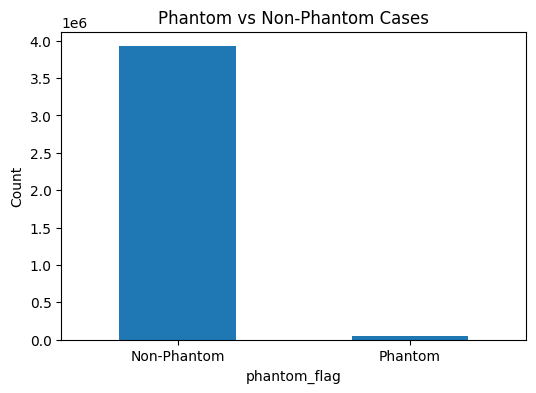

In [82]:
import matplotlib.pyplot as plt   
import pandas as pd

phantom_counts = inventory_model['phantom_flag'].value_counts().sort_index()

plt.figure(figsize=(6,4))
phantom_counts.plot(kind='bar')
plt.xticks([0,1], ['Non-Phantom', 'Phantom'], rotation=0)
plt.ylabel('Count')
plt.title('Phantom vs Non-Phantom Cases')
plt.show()

# 6. Inventory Movement & Shelf Gap Detection
Track inventory changes between snapshots and detect shelf gaps using expected stock versus actual shelf stock.

In [83]:
demand = (
    sales.groupby(['store_id', 'sku_id'])['units_sold']
    .mean()
    .reset_index(name='avg_daily_sales')
)

In [84]:
# 1. Average demand per store-SKU
demand = (
    sales.groupby(['store_id', 'sku_id'])['units_sold']
    .mean()
    .reset_index(name='avg_daily_sales')
)

# 2. Average stock per store-SKU
stock = (
    inventory.groupby(['store_id', 'sku_id'])
    .agg(
        avg_on_hand=('units_on_hand', 'mean'),
        avg_backroom=('units_in_backroom', 'mean'),
        avg_days_of_supply=('days_of_supply', 'mean')
    )
    .reset_index()
)

stock['total_avg_stock'] = stock['avg_on_hand'] + stock['avg_backroom']

# 3. Merge demand and stock
allocation_df = demand.merge(
    stock,
    on=['store_id', 'sku_id'],
    how='inner'
)

# 4. Add store and product context
allocation_df = allocation_df.merge(
    stores[['store_id', 'region', 'state', 'city', 'store_format', 'foot_traffic_tier']],
    on='store_id',
    how='left'
)

allocation_df = allocation_df.merge(
    products[['sku_id', 'product_name', 'category', 'subcategory', 'is_perishable',
              'reorder_point', 'safety_stock']],
    on='sku_id',
    how='left'
)

# 5. Stock-to-demand ratio
allocation_df['stock_to_demand'] = (
    allocation_df['total_avg_stock'] / (allocation_df['avg_daily_sales'] + 1)
)

# 6. Simple stock status buckets
allocation_df['stock_status'] = 'Healthy'
allocation_df.loc[allocation_df['stock_to_demand'] < 1, 'stock_status'] = 'Understock'
allocation_df.loc[allocation_df['stock_to_demand'] > 5, 'stock_status'] = 'Overstock'

# 7. View sample
allocation_df.head()

,store_id,sku_id,avg_daily_sales,avg_on_hand,avg_backroom,avg_days_of_supply,total_avg_stock,region,state,city,store_format,foot_traffic_tier,product_name,category,subcategory,is_perishable,reorder_point,safety_stock,stock_to_demand,stock_status
0,S0001,P00055,28.191518,110.561905,33.828571,4.737048,144.390476,Southwest,NY,New York,Convenience,Premium,ClearChoice Pure Sodas 12-Pack,Beverages,Sodas,False,146,73,4.946316,Healthy
1,S0001,P00078,4.444444,101.895238,21.400000,28.362476,123.295238,Southwest,NY,New York,Convenience,Premium,QuickFresh Deluxe Juices 1L,Beverages,Juices,False,114,57,22.646064,Overstock
2,S0001,P00084,25.299475,37.790476,126.590476,1.746857,164.380952,Southwest,NY,New York,Convenience,Premium,PureStart Light Sodas 12-Pack,Beverages,Sodas,False,71,36,6.250351,Overstock
3,S0001,P00096,29.584131,494.580952,165.361905,20.285714,659.942857,Southwest,NY,New York,Convenience,Premium,BrightBasket Lite Water 12-Pack,Beverages,Water,False,531,266,21.577950,Overstock
4,S0001,P00103,24.961696,334.790476,123.571429,16.555429,458.361905,Southwest,NY,New York,Convenience,Premium,SunValley Natural Sodas 24ct,Beverages,Sodas,False,362,181,17.655314,Overstock


In [85]:
region_profile = (
    allocation_df.groupby('region')
    .agg(
        avg_demand=('avg_daily_sales', 'mean'),
        avg_stock=('total_avg_stock', 'mean'),
        avg_ratio=('stock_to_demand', 'mean'),
        understock_rate=('stock_status', lambda x: (x == 'Understock').mean()),
        overstock_rate=('stock_status', lambda x: (x == 'Overstock').mean())
    )
    .reset_index()
    .sort_values(by='avg_ratio')
)

print(region_profile)

      region  avg_demand   avg_stock  avg_ratio  understock_rate  \
4  Southwest   11.318668  336.379038  44.040481              0.0   
2  Northwest   10.569036  335.232386  47.050799              0.0   
5       West   10.182128  335.260392  48.343625              0.0   
3  Southeast    9.811950  335.528877  48.853957              0.0   
1  Northeast    9.681748  338.093583  50.001594              0.0   
0    Midwest    9.311948  337.472802  52.666572              0.0   

   overstock_rate  
4        0.925602  
2        0.924038  
5        0.924716  
3        0.928993  
1        0.931395  
0        0.933333  


In [86]:
format_profile = (
    allocation_df.groupby('store_format')
    .agg(
        avg_demand=('avg_daily_sales', 'mean'),
        avg_stock=('total_avg_stock', 'mean'),
        avg_ratio=('stock_to_demand', 'mean'),
        understock_rate=('stock_status', lambda x: (x == 'Understock').mean()),
        overstock_rate=('stock_status', lambda x: (x == 'Overstock').mean())
    )
    .reset_index()
    .sort_values(by='avg_ratio')
)

print(format_profile)

  store_format  avg_demand   avg_stock  avg_ratio  understock_rate  \
0  Convenience   10.686477  333.897446  46.238878              0.0   
3  Supermarket   10.201436  337.410367  47.851355              0.0   
2  Hypermarket   10.010045  335.822285  48.586835              0.0   
4    Wholesale    9.941523  339.487926  49.626647              0.0   
1     Discount    9.842202  335.355157  50.339435              0.0   

   overstock_rate  
0        0.926875  
3        0.929000  
2        0.925000  
4        0.927948  
1        0.932447  


# 7. Store-SKU Allocation Analysis
Analyze average demand and average stock by store and SKU to identify overstock and understock patterns.

In [87]:
sku_location_profile = (
    allocation_df.groupby(['sku_id', 'product_name', 'region'])
    .agg(
        avg_demand=('avg_daily_sales', 'mean'),
        avg_stock=('total_avg_stock', 'mean'),
        avg_ratio=('stock_to_demand', 'mean')
    )
    .reset_index()
)

In [88]:
sku_imbalance = (
    allocation_df.groupby(['sku_id', 'product_name'])
    .agg(
        min_ratio=('stock_to_demand', 'min'),
        max_ratio=('stock_to_demand', 'max'),
        avg_ratio=('stock_to_demand', 'mean')
    )
    .reset_index()
)

sku_imbalance['imbalance_score'] = sku_imbalance['max_ratio'] - sku_imbalance['min_ratio']

sku_imbalance = sku_imbalance.sort_values(by='imbalance_score', ascending=False)

print(sku_imbalance.head(20))

      sku_id                             product_name  min_ratio   max_ratio  \
75    P00076             NovaBrand Organic Sodas 24ct  30.718285  743.042000   
16    P00017               EcoGreen Premium Juices 2L  30.520569  661.775758   
64    P00065                 EcoGreen Ultra Juices 2L  39.209104  661.407080   
11    P00012          TrueGrain Organic Water 12-Pack  35.596782  622.499912   
682   P00683      QuickFresh Natural Toothpaste 500ml  30.894178  614.942081   
625   P00626              CoastalFarms Bold Pizza 1kg  25.756516  573.853968   
469   P00470     CoastalFarms Family Size Rolls 500ml  34.966389  565.118440   
32    P00033         DailyEssentials Deluxe Juices 2L  28.804273  556.282801   
529   P00530        NovaBrand Organic Frozen Vegs 1kg  42.356367  566.706657   
974   P00975      DailyEssentials Bold Mushrooms 500g  25.986967  536.524749   
85    P00086     FreshMoment Bold Energy Drinks 500ml  26.119834  531.698495   
842   P00843        TrueGrain Natural Ch

In [89]:
understock_df = allocation_df[allocation_df['stock_status'] == 'Understock'].copy()
overstock_df = allocation_df[allocation_df['stock_status'] == 'Overstock'].copy()

print(understock_df[['store_id', 'sku_id', 'product_name', 'region', 'avg_daily_sales',
                     'total_avg_stock', 'stock_to_demand']].head(10))

print(overstock_df[['store_id', 'sku_id', 'product_name', 'region', 'avg_daily_sales',
                    'total_avg_stock', 'stock_to_demand']].head(10))

Empty DataFrame
Columns: [store_id, sku_id, product_name, region, avg_daily_sales, total_avg_stock, stock_to_demand]
Index: []
   store_id  sku_id                         product_name     region  \
1     S0001  P00078          QuickFresh Deluxe Juices 1L  Southwest   
2     S0001  P00084        PureStart Light Sodas 12-Pack  Southwest   
3     S0001  P00096      BrightBasket Lite Water 12-Pack  Southwest   
4     S0001  P00103         SunValley Natural Sodas 24ct  Southwest   
5     S0001  P00106           TrueGrain Crispy Juices 1L  Southwest   
7     S0001  P00155       UrbanHarvest Classic Yogurt 1L  Southwest   
8     S0001  P00164  DailyEssentials Natural Yogurt 500g  Southwest   
9     S0001  P00192         UrbanHarvest Ultra Milk 150g  Southwest   
10    S0001  P00203        GoldenLeaf Original Eggs 500g  Southwest   
11    S0001  P00221      HomeLine Extra Fresh Butter 1kg  Southwest   

    avg_daily_sales  total_avg_stock  stock_to_demand  
1          4.444444       123.29523

In [90]:
allocation_df['stock_status'] = 'Healthy'
allocation_df.loc[allocation_df['stock_to_demand'] < 1, 'stock_status'] = 'Understock'
allocation_df.loc[allocation_df['stock_to_demand'] > 5, 'stock_status'] = 'Overstock'

In [91]:
print(allocation_df['stock_status'].value_counts())

stock_status
Overstock    35492
Healthy       2748
Name: count, dtype: int64


In [92]:
understock_df = allocation_df[allocation_df['stock_status'] == 'Understock'].copy()
overstock_df = allocation_df[allocation_df['stock_status'] == 'Overstock'].copy()

In [93]:
print("Understock rows:", understock_df.shape)
print("Overstock rows:", overstock_df.shape)

print(overstock_df[['store_id', 'sku_id', 'product_name', 'region',
                    'avg_daily_sales', 'total_avg_stock', 'stock_to_demand']].head(10))

Understock rows: (0, 20)
Overstock rows: (35492, 20)
   store_id  sku_id                         product_name     region  \
1     S0001  P00078          QuickFresh Deluxe Juices 1L  Southwest   
2     S0001  P00084        PureStart Light Sodas 12-Pack  Southwest   
3     S0001  P00096      BrightBasket Lite Water 12-Pack  Southwest   
4     S0001  P00103         SunValley Natural Sodas 24ct  Southwest   
5     S0001  P00106           TrueGrain Crispy Juices 1L  Southwest   
7     S0001  P00155       UrbanHarvest Classic Yogurt 1L  Southwest   
8     S0001  P00164  DailyEssentials Natural Yogurt 500g  Southwest   
9     S0001  P00192         UrbanHarvest Ultra Milk 150g  Southwest   
10    S0001  P00203        GoldenLeaf Original Eggs 500g  Southwest   
11    S0001  P00221      HomeLine Extra Fresh Butter 1kg  Southwest   

    avg_daily_sales  total_avg_stock  stock_to_demand  
1          4.444444       123.295238        22.646064  
2         25.299475       164.380952         6.250351

In [94]:
region_analysis = (
    allocation_df.groupby('region')
    .agg(
        avg_ratio=('stock_to_demand', 'mean'),
        overstock_rate=('stock_status', lambda x: (x == 'Overstock').mean()),
        avg_stock=('total_avg_stock', 'mean'),
        avg_sales=('avg_daily_sales', 'mean')
    )
    .reset_index()
    .sort_values(by='avg_ratio', ascending=False)
)

print(region_analysis)

      region  avg_ratio  overstock_rate   avg_stock  avg_sales
0    Midwest  52.666572        0.933333  337.472802   9.311948
1  Northeast  50.001594        0.931395  338.093583   9.681748
3  Southeast  48.853957        0.928993  335.528877   9.811950
5       West  48.343625        0.924716  335.260392  10.182128
2  Northwest  47.050799        0.924038  335.232386  10.569036
4  Southwest  44.040481        0.925602  336.379038  11.318668


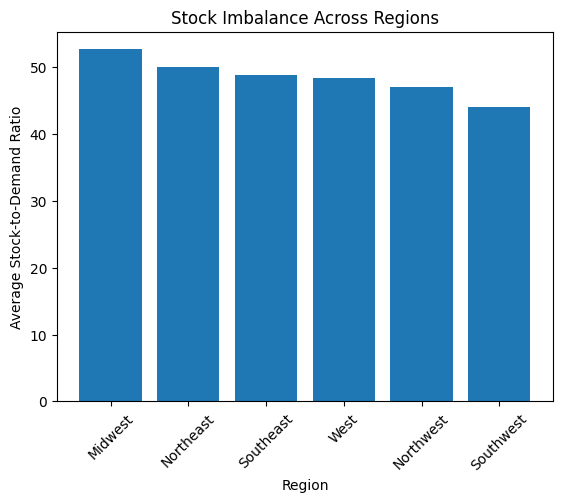

In [95]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(region_analysis['region'], region_analysis['avg_ratio'])
plt.xlabel('Region')
plt.ylabel('Average Stock-to-Demand Ratio')
plt.title('Stock Imbalance Across Regions')

plt.xticks(rotation=45)
plt.show()

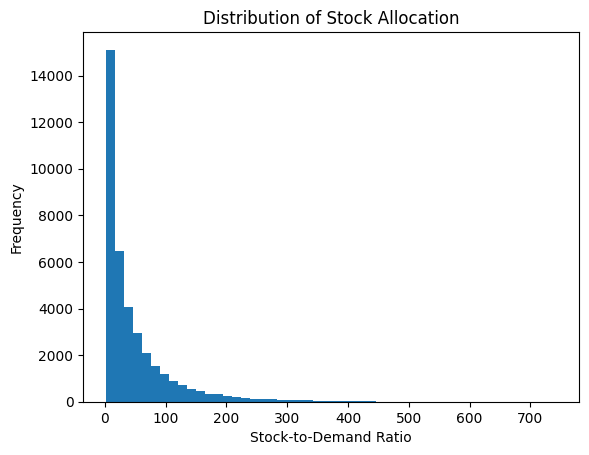

In [96]:
plt.figure()

plt.hist(allocation_df['stock_to_demand'], bins=50)
plt.xlabel('Stock-to-Demand Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Stock Allocation')

plt.show()

In [97]:
sales['week'] = pd.to_datetime(sales['sale_date']).dt.to_period('W')

sales_region = (
    sales.merge(stores[['store_id', 'region']], on='store_id')
    .groupby(['sku_id', 'region', 'week'])['units_sold']
    .sum()
    .reset_index()
)

In [98]:
recent_sales = (
    sales_region.sort_values('week')
    .groupby(['sku_id', 'region'])
    .tail(2)
    .groupby(['sku_id', 'region'])['units_sold']
    .mean()
    .reset_index(name='recent_demand')
)

historical_sales = (
    sales_region.sort_values('week')
    .groupby(['sku_id', 'region'])
    .apply(lambda x: x.iloc[:-2]['units_sold'].mean())
    .reset_index(name='historical_demand')
)

C:\Users\gowth\AppData\Local\Temp\ipykernel_21864\3505647077.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.iloc[:-2]['units_sold'].mean())


In [99]:
trend_df = recent_sales.merge(
    historical_sales,
    on=['sku_id', 'region'],
    how='left'
)

trend_df['demand_change'] = (
    trend_df['recent_demand'] - trend_df['historical_demand']
) / (trend_df['historical_demand'] + 1)

In [100]:
stock_region = (
    inventory.merge(stores[['store_id', 'region']], on='store_id')
    .groupby(['sku_id', 'region'])
    .agg(
        total_stock=('units_on_hand', 'mean')
    )
    .reset_index()
)

In [101]:
analysis = trend_df.merge(
    stock_region,
    on=['sku_id', 'region'],
    how='left'
)

In [102]:
low_demand = analysis[analysis['demand_change'] < -0.3]
high_demand = analysis[analysis['demand_change'] > 0.2]

redistribution = low_demand.merge(
    high_demand,
    on='sku_id',
    suffixes=('_low', '_high')
)

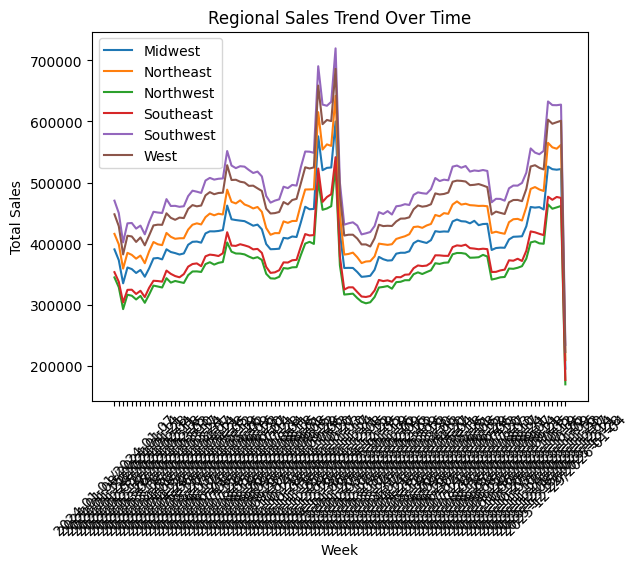

In [103]:
import matplotlib.pyplot as plt

# Prepare data
sales['week'] = pd.to_datetime(sales['sale_date']).dt.to_period('W')

sales_region = (
    sales.merge(stores[['store_id', 'region']], on='store_id')
    .groupby(['region', 'week'])['units_sold']
    .sum()
    .reset_index()
)

sales_region['week'] = sales_region['week'].astype(str)

# Plot
plt.figure()

for region in sales_region['region'].unique():
    region_data = sales_region[sales_region['region'] == region]
    plt.plot(region_data['week'], region_data['units_sold'], label=region)

plt.xlabel('Week')
plt.ylabel('Total Sales')
plt.title('Regional Sales Trend Over Time')
plt.xticks(rotation=45)
plt.legend()

plt.show()

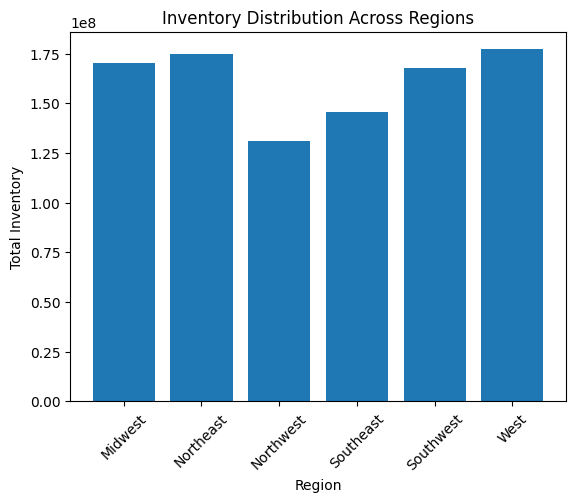

In [104]:
# Prepare inventory data
inventory_region = (
    inventory.merge(stores[['store_id', 'region']], on='store_id')
    .groupby('region')
    .agg(total_stock=('units_on_hand', 'sum'))
    .reset_index()
)

# Plot
plt.figure()

plt.bar(inventory_region['region'], inventory_region['total_stock'])

plt.xlabel('Region')
plt.ylabel('Total Inventory')
plt.title('Inventory Distribution Across Regions')

plt.xticks(rotation=45)
plt.show()

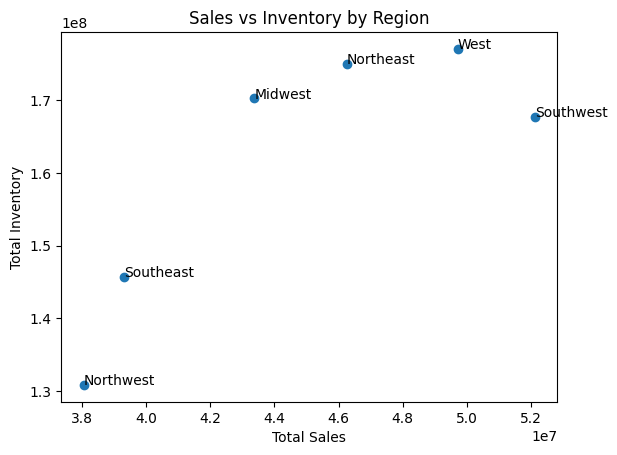

In [105]:
# Merge sales + inventory
sales_total = (
    sales.merge(stores[['store_id', 'region']], on='store_id')
    .groupby('region')['units_sold']
    .sum()
    .reset_index(name='total_sales')
)

inventory_total = (
    inventory.merge(stores[['store_id', 'region']], on='store_id')
    .groupby('region')['units_on_hand']
    .sum()
    .reset_index(name='total_stock')
)

region_compare = sales_total.merge(inventory_total, on='region')

# Plot
plt.figure()

plt.scatter(region_compare['total_sales'], region_compare['total_stock'])

for i, row in region_compare.iterrows():
    plt.text(row['total_sales'], row['total_stock'], row['region'])

plt.xlabel('Total Sales')
plt.ylabel('Total Inventory')
plt.title('Sales vs Inventory by Region')

plt.show()

In [106]:
top_skus = sales['sku_id'].value_counts().head(5).index.tolist()

In [107]:
sales['week'] = pd.to_datetime(sales['sale_date']).dt.to_period('W')

sales_region = (
    sales.merge(stores[['store_id', 'region']], on='store_id')
    .groupby(['sku_id', 'region', 'week'])['units_sold']
    .sum()
    .reset_index()
)

In [108]:
trend = (
    sales_region.sort_values('week')
    .groupby(['sku_id', 'region'])
    .apply(lambda x: pd.Series({
        'recent_sales': x.tail(2)['units_sold'].mean(),
        'past_sales': x.iloc[:-2]['units_sold'].mean()
    }))
    .reset_index()
)

trend['demand_change'] = (
    (trend['recent_sales'] - trend['past_sales']) /
    (trend['past_sales'] + 1)
)

C:\Users\gowth\AppData\Local\Temp\ipykernel_21864\2957388247.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


In [109]:
inventory_region = (
    inventory.merge(stores[['store_id', 'region']], on='store_id')
    .groupby(['sku_id', 'region'])
    .agg(avg_stock=('units_on_hand', 'mean'))
    .reset_index()
)

analysis = trend.merge(inventory_region, on=['sku_id', 'region'])

In [110]:
demand_drop = analysis[analysis['demand_change'] < -0.3]

In [111]:
demand_high = analysis[analysis['demand_change'] > 0.1]

In [112]:
redistribution_cases = demand_drop.merge(
    demand_high,
    on='sku_id',
    suffixes=('_low', '_high')
)

In [113]:
redistribution_cases = redistribution_cases[
    redistribution_cases['avg_stock_low'] > redistribution_cases['avg_stock_high']
]

In [114]:
print(redistribution_cases[
    ['sku_id',
     'region_low', 'recent_sales_low', 'avg_stock_low',
     'region_high', 'recent_sales_high', 'avg_stock_high']
].head(10))

    sku_id region_low  recent_sales_low  avg_stock_low region_high  \
0   P00150    Midwest             134.0      21.041270   Northeast   
3   P00300       West             197.0     120.607619     Midwest   
6   P00497       West              75.5      27.507937   Southeast   
7   P00591  Northeast              77.0      72.378571   Southwest   
8   P00597  Northwest             127.5      33.988095        West   
9   P00597  Southeast             361.0      35.007143        West   
11  P00664  Southeast             173.0      33.561905   Northwest   
15  P00892  Northeast             249.0      40.438095        West   
16  P00983  Southeast              83.5      23.268571   Northwest   
20  P01207  Southeast             109.0      38.073810        West   

    recent_sales_high  avg_stock_high  
0               147.0       18.038095  
3               297.0      120.100000  
6               245.0       26.504762  
7               421.0       61.558095  
8               493.0       3

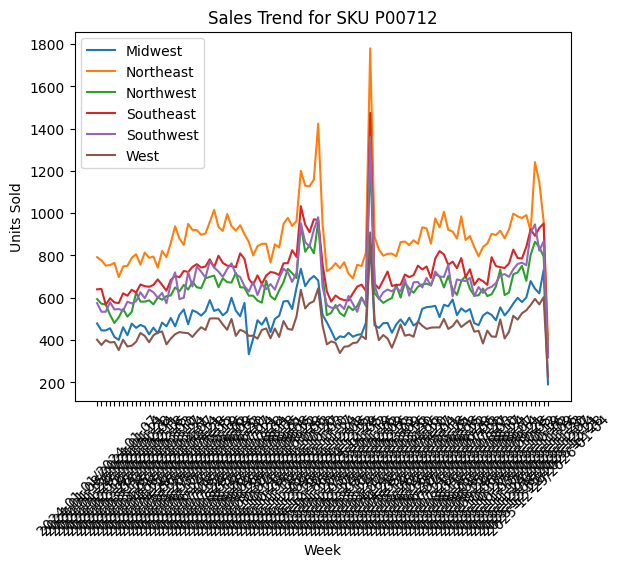

In [115]:
sku = top_skus[0]

sku_data = sales_region[sales_region['sku_id'] == sku]

plt.figure()

for region in sku_data['region'].unique():
    temp = sku_data[sku_data['region'] == region]
    plt.plot(temp['week'].astype(str), temp['units_sold'], label=region)

plt.title(f'Sales Trend for SKU {sku}')
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.xticks(rotation=45)
plt.legend()

plt.show()

# 8. Forecasting Dataset Creation
Build the modeling dataset using sales, inventory, product, store, promotion, and replenishment features.

In [116]:
# ============================================
# STEP 1: FINAL MASTER STATE TABLE
# Uses existing cleaned dataframes already in memory
# Do NOT reload or re-clean
# ============================================

import pandas as pd
import numpy as np

# -------------------------------
# 1. Start from inventory snapshot table
# -------------------------------
state = inventory.copy()
state = state.rename(columns={"snapshot_date": "date"})
state = state.sort_values(["store_id", "sku_id", "date"]).reset_index(drop=True)

state["total_stock"] = state["units_on_hand"] + state["units_in_backroom"]

In [117]:
# -------------------------------
# 2. Daily sales at store-SKU-date
# -------------------------------
sales_daily = (
    sales.groupby(["store_id", "sku_id", "sale_date"], as_index=False)
    .agg(
        daily_units_sold=("units_sold", "sum"),
        daily_revenue=("revenue", "sum")
    )
    .rename(columns={"sale_date": "date"})
    .sort_values(["store_id", "sku_id", "date"])
)

state = state.merge(
    sales_daily,
    on=["store_id", "sku_id", "date"],
    how="left"
)

state["daily_units_sold"] = state["daily_units_sold"].fillna(0)
state["daily_revenue"] = state["daily_revenue"].fillna(0)


In [118]:
# -------------------------------
# 3. Rolling sales features
# -------------------------------
state = state.sort_values(["store_id", "sku_id", "date"])

state["avg_sales_7d"] = (
    state.groupby(["store_id", "sku_id"])["daily_units_sold"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

state["avg_sales_14d"] = (
    state.groupby(["store_id", "sku_id"])["daily_units_sold"]
    .transform(lambda x: x.rolling(14, min_periods=1).mean())
)

state["sum_sales_7d"] = (
    state.groupby(["store_id", "sku_id"])["daily_units_sold"]
    .transform(lambda x: x.rolling(7, min_periods=1).sum())
)

state["sales_std_7d"] = (
    state.groupby(["store_id", "sku_id"])["daily_units_sold"]
    .transform(lambda x: x.rolling(7, min_periods=2).std())
    .fillna(0)
)

# weighted short-term demand estimate
state["demand_estimate"] = 0.7 * state["avg_sales_7d"] + 0.3 * state["avg_sales_14d"]


In [119]:
# -------------------------------
# 4. Last replenishment info WITHOUT future leakage
# -------------------------------
receipts_for_merge = (
    replenishment[
        ["store_id", "sku_id", "receive_date", "units_received", "lead_time_actual", "trigger_type"]
    ]
    .dropna(subset=["receive_date"])
    .copy()
)

# VERY IMPORTANT: sort by merge key first, then grouping keys
state = state.sort_values(["date", "store_id", "sku_id"]).reset_index(drop=True)
receipts_for_merge = receipts_for_merge.sort_values(
    ["receive_date", "store_id", "sku_id"]
).reset_index(drop=True)

state = pd.merge_asof(
    state,
    receipts_for_merge,
    left_on="date",
    right_on="receive_date",
    by=["store_id", "sku_id"],
    direction="backward"
)

state = state.rename(columns={
    "receive_date": "last_receive_date",
    "units_received": "last_units_received",
    "lead_time_actual": "last_lead_time_actual",
    "trigger_type": "last_trigger_type"
})

state["days_since_last_receipt"] = (state["date"] - state["last_receive_date"]).dt.days



In [120]:
state[["store_id", "sku_id", "date", "last_receive_date"]].head(10)

,store_id,sku_id,date,last_receive_date
0,S0001,P00055,2024-01-01,NaT
1,S0001,P00078,2024-01-01,NaT
2,S0001,P00084,2024-01-01,NaT
3,S0001,P00096,2024-01-01,NaT
4,S0001,P00103,2024-01-01,NaT
5,S0001,P00106,2024-01-01,NaT
6,S0001,P00113,2024-01-01,NaT
7,S0001,P00155,2024-01-01,NaT
8,S0001,P00164,2024-01-01,NaT
9,S0001,P00192,2024-01-01,NaT


In [121]:
# -------------------------------
# 5. Product + supplier + store context
# -------------------------------
product_cols = [
    "sku_id", "product_name", "brand", "category", "subcategory",
    "unit_price", "unit_cost", "is_perishable", "shelf_life_days",
    "supplier_id", "pack_size", "reorder_point", "safety_stock"
]

supplier_cols = [
    "supplier_id", "supplier_name", "lead_time_days_avg",
    "lead_time_days_std", "reliability_score", "min_order_qty"
]

store_cols = [
    "store_id", "region", "state", "city",
    "store_format", "foot_traffic_tier", "sq_footage"
]

state = state.merge(
    products[product_cols].drop_duplicates(subset=["sku_id"]),
    on="sku_id",
    how="left"
)

state = state.merge(
    suppliers[supplier_cols].drop_duplicates(subset=["supplier_id"]),
    on="supplier_id",
    how="left"
)

state = state.merge(
    stores[store_cols].drop_duplicates(subset=["store_id"]),
    on="store_id",
    how="left"
)

In [122]:
state[[
    "store_id", "sku_id", "date",
    "product_name", "category", "supplier_id",
    "lead_time_days_avg", "reliability_score",
    "region", "store_format"
]].head()

,store_id,sku_id,date,product_name,category,supplier_id,lead_time_days_avg,reliability_score,region,store_format
0,S0001,P00055,2024-01-01,ClearChoice Pure Sodas 12-Pack,Beverages,SUP020,16,0.747,Southwest,Convenience
1,S0001,P00078,2024-01-01,QuickFresh Deluxe Juices 1L,Beverages,SUP066,14,0.962,Southwest,Convenience
2,S0001,P00084,2024-01-01,PureStart Light Sodas 12-Pack,Beverages,SUP060,4,0.733,Southwest,Convenience
3,S0001,P00096,2024-01-01,BrightBasket Lite Water 12-Pack,Beverages,SUP081,19,0.734,Southwest,Convenience
4,S0001,P00103,2024-01-01,SunValley Natural Sodas 24ct,Beverages,SUP046,9,0.767,Southwest,Convenience


In [123]:
# -------------------------------
# 6. Layout features
# assigned_sku_id is the layout SKU key
# -------------------------------
layout_features = (
    store_layout.groupby(["store_id", "assigned_sku_id"], as_index=False)
    .agg(
        total_capacity_units=("capacity_units", "sum"),
        total_facing_count=("facing_count", "sum"),
        num_slots=("slot_id", "nunique"),
        num_shelves=("shelf_id", "nunique")
    )
    .rename(columns={"assigned_sku_id": "sku_id"})
)

state = state.merge(
    layout_features,
    on=["store_id", "sku_id"],
    how="left"
)

for col in ["total_capacity_units", "total_facing_count", "num_slots", "num_shelves"]:
    state[col] = state[col].fillna(0)

state["shelf_fill_ratio"] = np.where(
    state["total_capacity_units"] > 0,
    state["units_on_hand"] / state["total_capacity_units"],
    np.nan
)

In [124]:
state[[
    "store_id", "sku_id", "date",
    "units_on_hand",
    "total_capacity_units", "total_facing_count",
    "num_slots", "num_shelves", "shelf_fill_ratio"
]].head()

,store_id,sku_id,date,units_on_hand,total_capacity_units,total_facing_count,num_slots,num_shelves,shelf_fill_ratio
0,S0001,P00055,2024-01-01,349,0.0,0.0,0.0,0.0,NaN
1,S0001,P00078,2024-01-01,112,0.0,0.0,0.0,0.0,NaN
2,S0001,P00084,2024-01-01,328,0.0,0.0,0.0,0.0,NaN
3,S0001,P00096,2024-01-01,503,30.0,2.0,1.0,1.0,16.766667
4,S0001,P00103,2024-01-01,336,0.0,0.0,0.0,0.0,NaN


In [125]:
# -------------------------------
# 7. Promotion features (robust + memory-safe)
# -------------------------------

promo_cols = [
    "promotion_id", "sku_id", "store_id",
    "start_date", "end_date", "discount_pct", "demand_lift_factor"
]
promo = promotions[promo_cols].copy()
promo["store_id"] = promo["store_id"].fillna("ALL")

# create default promo columns first so they always exist
default_promo_cols = [
    "promo_active_store", "promo_discount_store", "promo_lift_store",
    "promo_active_all", "promo_discount_all", "promo_lift_all"
]
for col in default_promo_cols:
    state[col] = 0.0

all_dates = pd.DataFrame({
    "date": pd.to_datetime(state["date"].drop_duplicates().sort_values())
})

# ---- store-specific promotions ----
promo_store = promo[promo["store_id"] != "ALL"].copy()

if len(promo_store) > 0:
    promo_store_daily = (
        promo_store.merge(all_dates, how="cross")
        .loc[lambda x: (x["date"] >= x["start_date"]) & (x["date"] <= x["end_date"])]
        .groupby(["store_id", "sku_id", "date"], as_index=False)
        .agg(
            promo_active_store=("promotion_id", "size"),
            promo_discount_store=("discount_pct", "max"),
            promo_lift_store=("demand_lift_factor", "max")
        )
    )
    promo_store_daily["promo_active_store"] = 1

    state = state.merge(
        promo_store_daily,
        on=["store_id", "sku_id", "date"],
        how="left",
        suffixes=("", "_new")
    )

    for col in ["promo_active_store", "promo_discount_store", "promo_lift_store"]:
        if f"{col}_new" in state.columns:
            state[col] = state[f"{col}_new"].fillna(state[col])
            state.drop(columns=[f"{col}_new"], inplace=True)

# ---- ALL-store promotions ----
promo_all = promo[promo["store_id"] == "ALL"].copy()

if len(promo_all) > 0:
    promo_all_daily = (
        promo_all.merge(all_dates, how="cross")
        .loc[lambda x: (x["date"] >= x["start_date"]) & (x["date"] <= x["end_date"])]
        .groupby(["sku_id", "date"], as_index=False)
        .agg(
            promo_active_all=("promotion_id", "size"),
            promo_discount_all=("discount_pct", "max"),
            promo_lift_all=("demand_lift_factor", "max")
        )
    )
    promo_all_daily["promo_active_all"] = 1

    state = state.merge(
        promo_all_daily,
        on=["sku_id", "date"],
        how="left",
        suffixes=("", "_new")
    )

    for col in ["promo_active_all", "promo_discount_all", "promo_lift_all"]:
        if f"{col}_new" in state.columns:
            state[col] = state[f"{col}_new"].fillna(state[col])
            state.drop(columns=[f"{col}_new"], inplace=True)

# final promo columns
state["promo_active"] = (
    (state["promo_active_store"] > 0) |
    (state["promo_active_all"] > 0)
).astype(int)

state["promo_discount"] = state[["promo_discount_store", "promo_discount_all"]].max(axis=1)
state["promo_lift_factor"] = state[["promo_lift_store", "promo_lift_all"]].max(axis=1)

In [126]:
state[[
    "store_id", "sku_id", "date",
    "promo_active_store", "promo_active_all",
    "promo_active", "promo_discount", "promo_lift_factor"
]].head(10)

,store_id,sku_id,date,promo_active_store,promo_active_all,promo_active,promo_discount,promo_lift_factor
0,S0001,P00055,2024-01-01,0.0,0.0,0,0.0,0.0
1,S0001,P00078,2024-01-01,0.0,0.0,0,0.0,0.0
2,S0001,P00084,2024-01-01,0.0,0.0,0,0.0,0.0
3,S0001,P00096,2024-01-01,0.0,0.0,0,0.0,0.0
4,S0001,P00103,2024-01-01,0.0,0.0,0,0.0,0.0
5,S0001,P00106,2024-01-01,0.0,0.0,0,0.0,0.0
6,S0001,P00113,2024-01-01,0.0,0.0,0,0.0,0.0
7,S0001,P00155,2024-01-01,0.0,0.0,0,0.0,0.0
8,S0001,P00164,2024-01-01,0.0,0.0,0,0.0,0.0
9,S0001,P00192,2024-01-01,0.0,0.0,0,0.0,0.0


In [127]:
# -------------------------------
# Remove duplicate state rows created by promo joins
# Keep the "strongest" promo signal per store-SKU-date
# -------------------------------
# Remove duplicate state rows created by promo joins
# Keep strongest promo signal per store-SKU-date

state["promo_score"] = (
    state["promo_active"].fillna(0) * 100
    + state["promo_lift_factor"].fillna(0)
)

idx = (
    state.groupby(["store_id", "sku_id", "date"])["promo_score"]
    .idxmax()
)

state = state.loc[idx].reset_index(drop=True)

state = state.drop(columns=["promo_score"], errors="ignore")

state.shape

(4015200, 77)

In [128]:
print([c for c in state.columns if "perishable" in c.lower() or "shelf" in c.lower()])

['is_perishable_x', 'shelf_life_days_x', 'is_perishable_y', 'shelf_life_days_y', 'shelf_fill_ratio']


In [129]:
# add missing product fields safely
missing_product_cols = ["sku_id", "is_perishable", "shelf_life_days"]

state = state.merge(
    products[missing_product_cols].drop_duplicates(subset=["sku_id"]),
    on="sku_id",
    how="left",
    suffixes=("", "_prodfix")
)

# if duplicate/suffixed columns were created, standardize them
if "is_perishable_prodfix" in state.columns and "is_perishable" not in state.columns:
    state = state.rename(columns={"is_perishable_prodfix": "is_perishable"})

if "shelf_life_days_prodfix" in state.columns and "shelf_life_days" not in state.columns:
    state = state.rename(columns={"shelf_life_days_prodfix": "shelf_life_days"})

In [130]:
print("is_perishable" in state.columns)
print("shelf_life_days" in state.columns)

True
True


In [131]:
# -------------------------------
# 8. Core operational features
# -------------------------------
state["cover_days_est"] = np.where(
    state["demand_estimate"] > 0,
    state["total_stock"] / state["demand_estimate"],
    np.nan
)

state["backroom_ratio"] = np.where(
    state["total_stock"] > 0,
    state["units_in_backroom"] / state["total_stock"],
    0
)

state["low_shelf_flag"] = (state["units_on_hand"] <= 5).astype(int)
state["backroom_available_flag"] = (state["units_in_backroom"] > 0).astype(int)

state["shelf_gap_flag"] = (
    (state["units_on_hand"] <= 5) &
    (state["units_in_backroom"] > 0)
).astype(int)

# optional: stock pressure vs policy
state["below_reorder_flag"] = (state["total_stock"] <= state["reorder_point"]).astype(int)
state["below_safety_flag"] = (state["total_stock"] <= state["safety_stock"]).astype(int)

# -------------------------------
# 9. Final state table
# -------------------------------
final_cols = [
    "store_id", "sku_id", "date",
    "units_on_hand", "units_in_backroom", "total_stock", "days_of_supply",
    "daily_units_sold", "daily_revenue",
    "avg_sales_7d", "avg_sales_14d", "sum_sales_7d", "sales_std_7d", "demand_estimate",
    "last_receive_date", "last_units_received", "last_lead_time_actual", "last_trigger_type",
    "days_since_last_receipt",
    "product_name", "brand", "category", "subcategory",
    "unit_price", "unit_cost", "is_perishable", "shelf_life_days",
    "supplier_id", "supplier_name", "lead_time_days_avg", "lead_time_days_std",
    "reliability_score", "min_order_qty", "pack_size", "reorder_point", "safety_stock",
    "region", "state", "city", "store_format", "foot_traffic_tier", "sq_footage",
    "total_capacity_units", "total_facing_count", "num_slots", "num_shelves", "shelf_fill_ratio",
    "promo_active", "promo_discount", "promo_lift_factor",
    "cover_days_est", "backroom_ratio",
    "low_shelf_flag", "backroom_available_flag", "shelf_gap_flag",
    "below_reorder_flag", "below_safety_flag"
]

state_final = state[final_cols].copy()

print("state_final shape:", state_final.shape)
print("duplicate rows:", state_final.duplicated(subset=["store_id", "sku_id", "date"]).sum())

state_final.head()

state_final shape: (4015200, 57)
duplicate rows: 0


,store_id,sku_id,date,units_on_hand,units_in_backroom,total_stock,days_of_supply,daily_units_sold,daily_revenue,avg_sales_7d,...,promo_active,promo_discount,promo_lift_factor,cover_days_est,backroom_ratio,low_shelf_flag,backroom_available_flag,shelf_gap_flag,below_reorder_flag,below_safety_flag
0,S0001,P00055,2024-01-01,349,0,349,12.29,31.0,1223.57,31.00,...,0,0.0,0.0,11.258065,0.000000,0,0,0,0,0
1,S0001,P00055,2024-01-08,172,0,172,8.48,19.0,749.93,25.00,...,0,0.0,0.0,6.880000,0.000000,0,0,0,0,0
2,S0001,P00055,2024-01-15,112,61,173,5.52,34.0,1341.98,28.00,...,0,0.0,0.0,6.178571,0.352601,0,1,0,0,0
3,S0001,P00055,2024-01-22,123,64,187,6.06,23.0,907.81,26.75,...,0,0.0,0.0,6.990654,0.342246,0,1,0,0,0
4,S0001,P00055,2024-01-29,130,69,199,6.41,16.0,631.52,24.60,...,0,0.0,0.0,8.089431,0.346734,0,1,0,0,0


In [132]:
feature_cols = [
    "daily_units_sold",
    "avg_sales_7d",
    "avg_sales_14d",
    "sales_std_7d",
    "total_stock",
    "units_on_hand",
    "units_in_backroom",
    "days_of_supply",
    "cover_days_est",
    "promo_active",
    "promo_discount",
    "promo_lift_factor",
    "lead_time_days_avg",
    "lead_time_days_std",
    "reliability_score",
    "reorder_point",
    "safety_stock",
    "shelf_fill_ratio",
    "backroom_ratio"
]

model_cols = ["store_id", "sku_id", "date"] + feature_cols

df_model = state_final[model_cols].copy()
df_model = df_model.sort_values(["store_id", "sku_id", "date"]).reset_index(drop=True)

df_model["target_next_day_sales"] = (
    df_model.groupby(["store_id", "sku_id"])["daily_units_sold"].shift(-1)
)

df_model = df_model[df_model["target_next_day_sales"].notna()].reset_index(drop=True)

In [133]:
print(df_model.shape)
df_model.head()

(3976960, 23)


,store_id,sku_id,date,daily_units_sold,avg_sales_7d,avg_sales_14d,sales_std_7d,total_stock,units_on_hand,units_in_backroom,...,promo_discount,promo_lift_factor,lead_time_days_avg,lead_time_days_std,reliability_score,reorder_point,safety_stock,shelf_fill_ratio,backroom_ratio,target_next_day_sales
0,S0001,P00055,2024-01-01,31.0,31.00,31.00,0.000000,349,349,0,...,0.0,0.0,16,3.2,0.747,146,73,NaN,0.000000,19.0
1,S0001,P00055,2024-01-08,19.0,25.00,25.00,8.485281,172,172,0,...,0.0,0.0,16,3.2,0.747,146,73,NaN,0.000000,34.0
2,S0001,P00055,2024-01-15,34.0,28.00,28.00,7.937254,173,112,61,...,0.0,0.0,16,3.2,0.747,146,73,NaN,0.352601,23.0
3,S0001,P00055,2024-01-22,23.0,26.75,26.75,6.946222,187,123,64,...,0.0,0.0,16,3.2,0.747,146,73,NaN,0.342246,16.0
4,S0001,P00055,2024-01-29,16.0,24.60,24.60,7.700649,199,130,69,...,0.0,0.0,16,3.2,0.747,146,73,NaN,0.346734,15.0


# 9. Time-Based Train-Test Split
Split the modeling dataset chronologically to avoid future data leakage.

In [134]:
split_date = df_model["date"].quantile(0.8)

train_df = df_model[df_model["date"] <= split_date]
test_df  = df_model[df_model["date"] > split_date]

X_train = train_df[feature_cols]
y_train = train_df["target_next_day_sales"]

X_test = test_df[feature_cols]
y_test = test_df["target_next_day_sales"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Split date:", split_date)

Train shape: (3212160, 19)
Test shape: (764800, 19)
Split date: 2025-08-04 00:00:00


In [135]:
import sys
!{sys.executable} -m pip install xgboost scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 10. Demand Forecasting Model Comparison
Train and compare Linear Regression, Random Forest, and XGBoost models using MAE and RMSE.

In [136]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)




MAE: 2.813829295193009
RMSE: 4.265999309144291


In [137]:
X_train.isna().sum().sort_values(ascending=False)

shelf_fill_ratio      1652952
cover_days_est           3319
daily_units_sold            0
avg_sales_14d               0
avg_sales_7d                0
units_on_hand               0
sales_std_7d                0
units_in_backroom           0
days_of_supply              0
promo_active                0
total_stock                 0
promo_discount              0
promo_lift_factor           0
lead_time_days_std          0
lead_time_days_avg          0
reliability_score           0
reorder_point               0
safety_stock                0
backroom_ratio              0
dtype: int64

In [138]:
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

In [139]:
X_train_lr.isna().sum().sort_values(ascending=False)

shelf_fill_ratio      1652952
cover_days_est           3319
daily_units_sold            0
avg_sales_14d               0
avg_sales_7d                0
units_on_hand               0
sales_std_7d                0
units_in_backroom           0
days_of_supply              0
promo_active                0
total_stock                 0
promo_discount              0
promo_lift_factor           0
lead_time_days_std          0
lead_time_days_avg          0
reliability_score           0
reorder_point               0
safety_stock                0
backroom_ratio              0
dtype: int64

In [140]:
X_train_lr = X_train_lr.drop(columns=["shelf_fill_ratio"])
X_test_lr = X_test_lr.drop(columns=["shelf_fill_ratio"])

In [141]:
X_train_lr = X_train_lr.fillna(X_train_lr.median())
X_test_lr = X_test_lr.fillna(X_train_lr.median())

In [142]:
print("Train NaNs:", X_train_lr.isna().sum().sum())
print("Test NaNs:", X_test_lr.isna().sum().sum())

Train NaNs: 0
Test NaNs: 0


In [143]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lr_model = LinearRegression()

lr_model.fit(X_train_lr, y_train)

y_pred_lr = lr_model.predict(X_test_lr)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 3.041307749672991
Linear Regression RMSE: 4.626541296469217


In [144]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_lr, y_train)

y_pred_rf = rf_model.predict(X_test_lr)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 2.8970625850010387
Random Forest RMSE: 4.373340379570634


# 11. Final Forecast Output
Use the best model predictions to create the final predicted demand column for downstream decision logic.

In [145]:
mae_xgb = mae
rmse_xgb = rmse
y_pred_xgb = y_pred

model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [mae_lr, mae_rf, mae_xgb],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb]
}).sort_values("RMSE")

model_comparison

,Model,MAE,RMSE
2,XGBoost,2.813829,4.265999
1,Random Forest,2.897063,4.373340
0,Linear Regression,3.041308,4.626541


# 12. Stockout Risk Detection
Convert forecasted demand into stockout risk using expected stock and threshold-based rules.

In [146]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df.head(10))

              feature  importance
2       avg_sales_14d    0.712466
1        avg_sales_7d    0.150340
4         total_stock    0.020412
3        sales_std_7d    0.017140
6   units_in_backroom    0.016928
0    daily_units_sold    0.015371
8      cover_days_est    0.010562
7      days_of_supply    0.010183
18     backroom_ratio    0.008880
16       safety_stock    0.007849


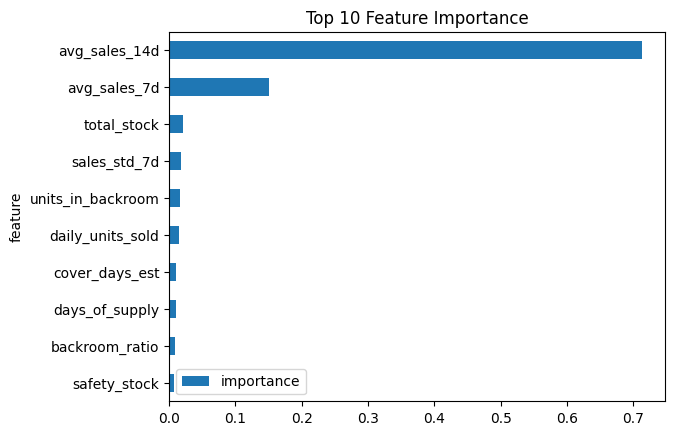

In [147]:
import matplotlib.pyplot as plt

importance_df.head(10).plot(
    kind="barh", x="feature", y="importance"
)
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.show()

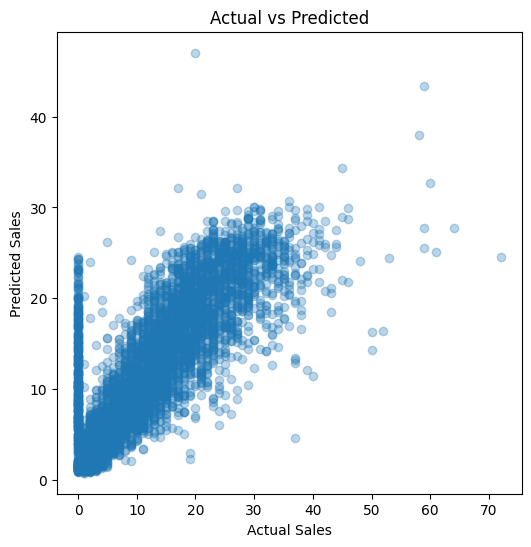

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test[:5000], y_pred[:5000], alpha=0.3)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

Stockout risk

In [149]:
df_eval = test_df.copy()
df_eval["predicted_sales"] = y_pred

df_eval[[
    "store_id", "sku_id", "date",
    "total_stock", "target_next_day_sales", "predicted_sales"
]].head()

,store_id,sku_id,date,total_stock,target_next_day_sales,predicted_sales
84,S0001,P00055,2025-08-11,104,25.0,21.372358
85,S0001,P00055,2025-08-18,63,25.0,22.203703
86,S0001,P00055,2025-08-25,233,21.0,23.495882
87,S0001,P00055,2025-09-01,23,22.0,22.049927
88,S0001,P00055,2025-09-08,204,12.0,22.376339


In [150]:
df_eval["expected_stock"] = df_eval["total_stock"] - df_eval["predicted_sales"]

df_eval[[
    "store_id", "sku_id", "date",
    "total_stock", "predicted_sales", "expected_stock"
]].head()

,store_id,sku_id,date,total_stock,predicted_sales,expected_stock
84,S0001,P00055,2025-08-11,104,21.372358,82.627642
85,S0001,P00055,2025-08-18,63,22.203703,40.796297
86,S0001,P00055,2025-08-25,233,23.495882,209.504118
87,S0001,P00055,2025-09-01,23,22.049927,0.950073
88,S0001,P00055,2025-09-08,204,22.376339,181.623661


In [151]:
stockout_threshold = 2

df_eval["stockout_risk"] = (
    df_eval["expected_stock"] <= stockout_threshold
).astype(int)

df_eval["stockout_risk"].value_counts()

stockout_risk
0    723063
1     41737
Name: count, dtype: int64

# 13. Exception Detection
Detect abnormal inventory situations such as phantom inventory and classify each SKU-store-date into risk categories.

In [152]:
df_eval["phantom_flag_rule"] = (
    (df_eval["total_stock"] > 10) &
    (df_eval["predicted_sales"] < 2)
).astype(int)

df_eval["phantom_flag_rule"].value_counts()

phantom_flag_rule
0    681447
1     83353
Name: count, dtype: int64

In [153]:
def classify_risk(row):
    if row["stockout_risk"] == 1:
        return "Stockout Risk"
    elif row["phantom_flag_rule"] == 1:
        return "Phantom Inventory"
    else:
        return "Normal"

df_eval["risk_category"] = df_eval.apply(classify_risk, axis=1)

df_eval["risk_category"].value_counts()

risk_category
Normal               639710
Phantom Inventory     83353
Stockout Risk         41737
Name: count, dtype: int64

In [154]:
df_eval[df_eval["risk_category"] != "Normal"][[
    "store_id", "sku_id", "date",
    "total_stock", "predicted_sales", "expected_stock",
    "stockout_risk", "phantom_flag_rule", "risk_category"
]].head(20)

,store_id,sku_id,date,total_stock,predicted_sales,expected_stock,stockout_risk,phantom_flag_rule,risk_category
87,S0001,P00055,2025-09-01,23,22.049927,0.950073,1,0,Stockout Risk
293,S0001,P00084,2025-08-18,0,18.834106,-18.834106,1,0,Stockout Risk
296,S0001,P00084,2025-09-08,0,17.819946,-17.819946,1,0,Stockout Risk
299,S0001,P00084,2025-09-29,0,16.879942,-16.879942,1,0,Stockout Risk
302,S0001,P00084,2025-10-20,0,17.651331,-17.651331,1,0,Stockout Risk
305,S0001,P00084,2025-11-10,0,17.318321,-17.318321,1,0,Stockout Risk
306,S0001,P00084,2025-11-17,0,15.460781,-15.460781,1,0,Stockout Risk
309,S0001,P00084,2025-12-08,0,16.828207,-16.828207,1,0,Stockout Risk
724,S0001,P00113,2025-12-01,0,21.260342,-21.260342,1,0,Stockout Risk
726,S0001,P00113,2025-12-15,11,21.754166,-10.754166,1,0,Stockout Risk


In [155]:
def recommend_action(row):
    
    # 🚨 Stockout risk → replenish
    if row["stockout_risk"] == 1:
        return "Replenish Immediately"
    
    # 👻 Phantom inventory → investigate
    elif row["phantom_flag_rule"] == 1:
        return "Check Shelf / Misplacement"
    
    # ✅ Normal → no action
    else:
        return "No Action Needed"

df_eval["action"] = df_eval.apply(recommend_action, axis=1)

df_eval["action"].value_counts()

action
No Action Needed              639710
Check Shelf / Misplacement     83353
Replenish Immediately          41737
Name: count, dtype: int64

In [156]:
df_eval["priority_score"] = (
    df_eval["predicted_sales"] / (df_eval["total_stock"] + 1)
)

In [157]:
df_eval["priority_score"] = (
    df_eval["predicted_sales"] / (df_eval["total_stock"] + 1)
)

In [158]:
df_eval.sort_values("priority_score", ascending=False)[[
    "store_id", "sku_id", "date",
    "total_stock", "predicted_sales",
    "expected_stock", "risk_category",
    "action", "priority_score"
]].head(20)

,store_id,sku_id,date,total_stock,predicted_sales,expected_stock,risk_category,action,priority_score
3573533,S0430,P00555,2025-10-13,0,34.606190,-34.606190,Stockout Risk,Replenish Immediately,34.606190
2585218,S0311,P00961,2025-09-22,0,30.956646,-30.956646,Stockout Risk,Replenish Immediately,30.956646
3675148,S0442,P00926,2025-12-01,0,30.657721,-30.657721,Stockout Risk,Replenish Immediately,30.657721
2815482,S0339,P00537,2025-11-17,0,30.504017,-30.504017,Stockout Risk,Replenish Immediately,30.504017
2399678,S0289,P00545,2025-08-25,0,30.250721,-30.250721,Stockout Risk,Replenish Immediately,30.250721
3654646,S0440,P00382,2025-08-25,0,29.807457,-29.807457,Stockout Risk,Replenish Immediately,29.807457
3427942,S0413,P00006,2025-12-15,0,29.674212,-29.674212,Stockout Risk,Replenish Immediately,29.674212
1466084,S0177,P00262,2025-12-01,0,29.589308,-29.589308,Stockout Risk,Replenish Immediately,29.589308
1259955,S0152,P00537,2025-11-24,0,29.374678,-29.374678,Stockout Risk,Replenish Immediately,29.374678
45236,S0006,P00478,2025-12-01,0,28.986101,-28.986101,Stockout Risk,Replenish Immediately,28.986101


In [159]:
summary = df_eval.groupby("action").agg({
    "sku_id": "count",
    "predicted_sales": "mean"
}).rename(columns={"sku_id": "count"})

summary

,count,predicted_sales
action,,
Check Shelf / Misplacement,83353,1.244967
No Action Needed,639710,9.268497
Replenish Immediately,41737,11.616204


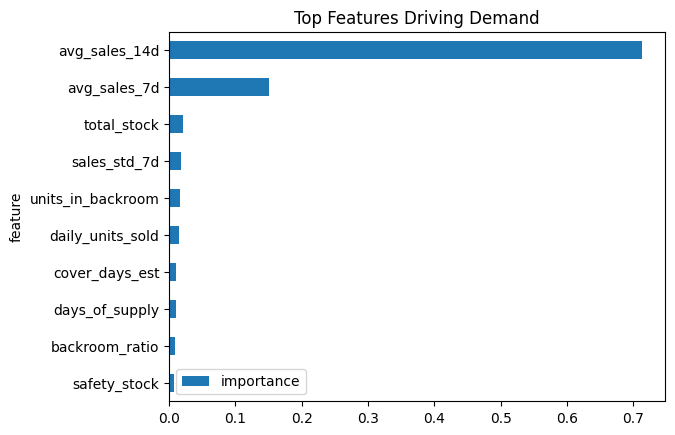

In [160]:
import matplotlib.pyplot as plt

importance_df.head(10).plot(
    kind="barh", x="feature", y="importance"
)
plt.gca().invert_yaxis()
plt.title("Top Features Driving Demand")
plt.show()

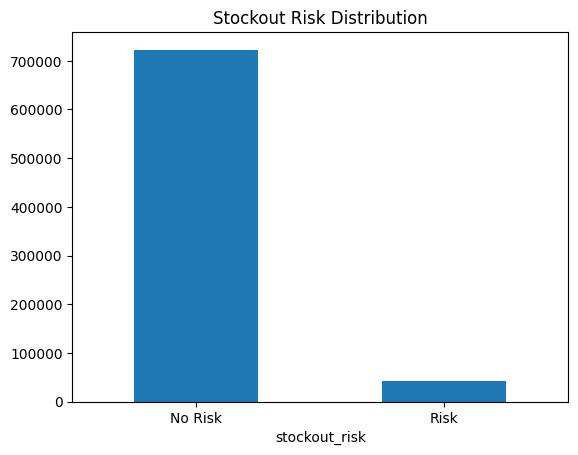

In [161]:
df_eval["stockout_risk"].value_counts().plot(kind="bar")
plt.title("Stockout Risk Distribution")
plt.xticks([0,1], ["No Risk", "Risk"], rotation=0)
plt.show()

In [162]:
df_eval.groupby("stockout_risk")[[
    "predicted_sales", "total_stock"
]].mean()

,predicted_sales,total_stock
stockout_risk,,
0,8.343563,350.472472
1,11.616204,1.324197


In [163]:
df_eval.groupby("stockout_risk")[[
    "predicted_sales", "total_stock"
]].mean()

,predicted_sales,total_stock
stockout_risk,,
0,8.343563,350.472472
1,11.616204,1.324197


In [164]:
df_eval[df_eval["risk_category"] != "Normal"].sort_values(
    "priority_score", ascending=False
).head(10)

,store_id,sku_id,date,daily_units_sold,avg_sales_7d,avg_sales_14d,sales_std_7d,total_stock,units_on_hand,units_in_backroom,...,shelf_fill_ratio,backroom_ratio,target_next_day_sales,predicted_sales,expected_stock,stockout_risk,phantom_flag_rule,risk_category,action,priority_score
3573533,S0430,P00555,2025-10-13,41.0,29.428571,27.571429,8.638232,0,0,0,...,0.0,0.0,36.0,34.606190,-34.606190,1,0,Stockout Risk,Replenish Immediately,34.606190
2585218,S0311,P00961,2025-09-22,0.0,26.571429,25.714286,16.801360,0,0,0,...,NaN,0.0,31.0,30.956646,-30.956646,1,0,Stockout Risk,Replenish Immediately,30.956646
3675148,S0442,P00926,2025-12-01,67.0,34.571429,27.214286,20.687010,0,0,0,...,NaN,0.0,0.0,30.657721,-30.657721,1,0,Stockout Risk,Replenish Immediately,30.657721
2815482,S0339,P00537,2025-11-17,0.0,31.000000,28.714286,25.468935,0,0,0,...,NaN,0.0,88.0,30.504017,-30.504017,1,0,Stockout Risk,Replenish Immediately,30.504017
2399678,S0289,P00545,2025-08-25,0.0,36.000000,29.714286,26.751947,0,0,0,...,0.0,0.0,26.0,30.250721,-30.250721,1,0,Stockout Risk,Replenish Immediately,30.250721
3654646,S0440,P00382,2025-08-25,0.0,29.857143,25.785714,17.883219,0,0,0,...,0.0,0.0,27.0,29.807457,-29.807457,1,0,Stockout Risk,Replenish Immediately,29.807457
3427942,S0413,P00006,2025-12-15,9.0,29.142857,27.214286,11.260973,0,0,0,...,NaN,0.0,22.0,29.674212,-29.674212,1,0,Stockout Risk,Replenish Immediately,29.674212
1466084,S0177,P00262,2025-12-01,0.0,20.857143,20.857143,12.759684,0,0,0,...,NaN,0.0,22.0,29.589308,-29.589308,1,0,Stockout Risk,Replenish Immediately,29.589308
1259955,S0152,P00537,2025-11-24,0.0,29.142857,24.000000,22.777391,0,0,0,...,NaN,0.0,20.0,29.374678,-29.374678,1,0,Stockout Risk,Replenish Immediately,29.374678
45236,S0006,P00478,2025-12-01,68.0,36.000000,31.285714,18.018509,0,0,0,...,NaN,0.0,35.0,28.986101,-28.986101,1,0,Stockout Risk,Replenish Immediately,28.986101


# 14. Cause Labeling
Assign likely business causes behind inventory issues such as demand spike, supplier delay, phantom inventory, and shelf/manual issues.

In [165]:
def assign_cause_label(row):
    # 1. Phantom / shrinkage style issue
    if row["phantom_flag_rule"] == 1:
        return "Phantom / Shrinkage"
    
    # 2. Shelf / manual issue
    elif (
        ("units_in_backroom" in row.index) and
        ("units_on_hand" in row.index) and
        (row["units_on_hand"] <= 5) and
        (row["units_in_backroom"] > 0)
    ):
        return "Shelf / Manual Issue"
    
    # 3. Demand spike
    elif (
        row["stockout_risk"] == 1 and
        row["predicted_sales"] > 1.3 * row["avg_sales_14d"]
    ):
        return "Demand Spike"
    
    # 4. Supplier delay
    elif (
        row["stockout_risk"] == 1 and
        ("days_since_last_receipt" in row.index) and
        ("lead_time_days_avg" in row.index) and
        ("reliability_score" in row.index) and
        (
            (row["days_since_last_receipt"] > row["lead_time_days_avg"]) or
            (row["reliability_score"] < 0.80)
        )
    ):
        return "Supplier Delay"
    
    # 5. Overstock / slow mover
    elif (
        ("stock_to_demand" in row.index) and
        (row["stock_to_demand"] > 5) and
        (row["predicted_sales"] < row["avg_sales_7d"])
    ):
        return "Overstock / Slow Mover"
    
    else:
        return "Normal"

In [166]:
df_eval["cause_label"] = df_eval.apply(assign_cause_label, axis=1)

df_eval["cause_label"].value_counts()

cause_label
Normal                  661684
Phantom / Shrinkage      83353
Shelf / Manual Issue     13139
Demand Spike              6624
Name: count, dtype: int64

In [167]:
df_eval[[
    "store_id", "sku_id", "date",
    "total_stock", "predicted_sales", "expected_stock",
    "stockout_risk", "phantom_flag_rule",
    "avg_sales_7d", "avg_sales_14d",
    "cause_label"
]].head(20)

,store_id,sku_id,date,total_stock,predicted_sales,expected_stock,stockout_risk,phantom_flag_rule,avg_sales_7d,avg_sales_14d,cause_label
84,S0001,P00055,2025-08-11,104,21.372358,82.627642,0,0,22.142857,23.071429,Normal
85,S0001,P00055,2025-08-18,63,22.203703,40.796297,0,0,22.714286,23.357143,Normal
86,S0001,P00055,2025-08-25,233,23.495882,209.504118,0,0,22.571429,23.428571,Normal
87,S0001,P00055,2025-09-01,23,22.049927,0.950073,1,0,22.571429,23.000000,Normal
88,S0001,P00055,2025-09-08,204,22.376339,181.623661,0,0,23.571429,23.000000,Normal
89,S0001,P00055,2025-09-15,216,20.974623,195.025377,0,0,20.714286,22.142857,Normal
90,S0001,P00055,2025-09-22,229,21.591965,207.408035,0,0,20.857143,21.571429,Normal
91,S0001,P00055,2025-09-29,206,21.670515,184.329485,0,0,21.428571,21.785714,Normal
92,S0001,P00055,2025-10-06,181,20.606350,160.393650,0,0,21.857143,22.285714,Normal
93,S0001,P00055,2025-10-13,181,20.445057,160.554943,0,0,22.428571,22.500000,Normal


In [168]:
df_eval[df_eval["cause_label"] != "Normal"][[
    "store_id", "sku_id", "date",
    "total_stock", "predicted_sales", "expected_stock",
    "stockout_risk", "phantom_flag_rule",
    "avg_sales_7d", "avg_sales_14d",
    "cause_label"
]].head(30)

,store_id,sku_id,date,total_stock,predicted_sales,expected_stock,stockout_risk,phantom_flag_rule,avg_sales_7d,avg_sales_14d,cause_label
302,S0001,P00084,2025-10-20,0,17.651331,-17.651331,1,0,12.000000,13.214286,Demand Spike
305,S0001,P00084,2025-11-10,0,17.318321,-17.318321,1,0,12.714286,13.214286,Demand Spike
306,S0001,P00084,2025-11-17,0,15.460781,-15.460781,1,0,12.714286,11.785714,Demand Spike
309,S0001,P00084,2025-12-08,0,16.828207,-16.828207,1,0,13.857143,12.928571,Demand Spike
1540,S0001,P00277,2025-08-11,844,1.936340,842.063660,0,1,1.714286,1.714286,Phantom / Shrinkage
1541,S0001,P00277,2025-08-18,824,1.939726,822.060274,0,1,1.857143,1.714286,Phantom / Shrinkage
1542,S0001,P00277,2025-08-25,794,1.969456,792.030544,0,1,2.000000,1.785714,Phantom / Shrinkage
1543,S0001,P00277,2025-09-01,760,1.940251,758.059749,0,1,2.000000,1.857143,Phantom / Shrinkage
1544,S0001,P00277,2025-09-08,737,1.991291,735.008709,0,1,2.428571,2.000000,Phantom / Shrinkage
2581,S0001,P00488,2025-08-18,0,6.717947,-6.717947,1,0,5.714286,5.142857,Demand Spike


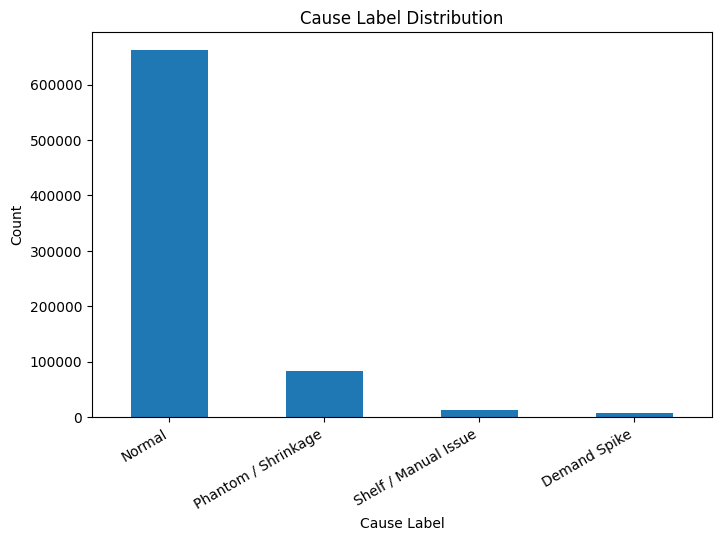

In [169]:
import matplotlib.pyplot as plt

cause_counts = df_eval["cause_label"].value_counts()

plt.figure(figsize=(8,5))
cause_counts.plot(kind="bar")
plt.title("Cause Label Distribution")
plt.xlabel("Cause Label")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.show()

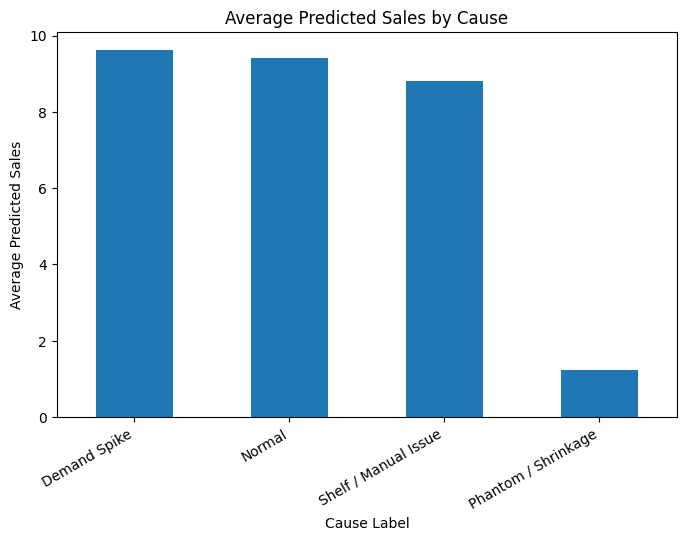

In [170]:
cause_demand = (
    df_eval.groupby("cause_label")["predicted_sales"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
cause_demand.plot(kind="bar")
plt.title("Average Predicted Sales by Cause")
plt.xlabel("Cause Label")
plt.ylabel("Average Predicted Sales")
plt.xticks(rotation=30, ha="right")
plt.show()

# 15. Action Engine
Convert detected risks and cause labels into recommended business actions and priority scores.

In [171]:


transfer_df = df_eval.copy()

# donor = enough stock, low risk
transfer_df["donor_flag"] = (
    (transfer_df["total_stock"] > transfer_df["safety_stock"]) &
    (transfer_df["stockout_risk"] == 0)
).astype(int)

# receiver = stockout risk or understock-like condition
transfer_df["receiver_flag"] = (
    (transfer_df["stockout_risk"] == 1) |
    (transfer_df["expected_stock"] <= 2)
).astype(int)

# donor excess above safety stock
transfer_df["donor_excess_stock"] = (
    transfer_df["total_stock"] - transfer_df["safety_stock"]
).clip(lower=0)

# receiver shortage amount
transfer_df["receiver_required_stock"] = (
    transfer_df["predicted_sales"] - transfer_df["expected_stock"]
).clip(lower=0)

print("Donor stores:", transfer_df["donor_flag"].sum())
print("Receiver stores:", transfer_df["receiver_flag"].sum())

Donor stores: 693143
Receiver stores: 41737


In [172]:
print(transfer_df.columns.tolist())

['store_id', 'sku_id', 'date', 'daily_units_sold', 'avg_sales_7d', 'avg_sales_14d', 'sales_std_7d', 'total_stock', 'units_on_hand', 'units_in_backroom', 'days_of_supply', 'cover_days_est', 'promo_active', 'promo_discount', 'promo_lift_factor', 'lead_time_days_avg', 'lead_time_days_std', 'reliability_score', 'reorder_point', 'safety_stock', 'shelf_fill_ratio', 'backroom_ratio', 'target_next_day_sales', 'predicted_sales', 'expected_stock', 'stockout_risk', 'phantom_flag_rule', 'risk_category', 'action', 'priority_score', 'cause_label', 'donor_flag', 'receiver_flag', 'donor_excess_stock', 'receiver_required_stock']


In [173]:


donors = transfer_df[transfer_df["donor_flag"] == 1][[
    "store_id", "sku_id", "date",
    "total_stock", "safety_stock",
    "donor_excess_stock", "predicted_sales"
]].copy()

receivers = transfer_df[transfer_df["receiver_flag"] == 1][[
    "store_id", "sku_id", "date",
    "total_stock", "expected_stock",
    "receiver_required_stock", "predicted_sales"
]].copy()

donors = donors.rename(columns={
    "store_id": "donor_store_id",
    "total_stock": "donor_total_stock",
    "predicted_sales": "donor_predicted_sales"
})

receivers = receivers.rename(columns={
    "store_id": "receiver_store_id",
    "total_stock": "receiver_total_stock",
    "predicted_sales": "receiver_predicted_sales"
})

print("Donors shape:", donors.shape)
print("Receivers shape:", receivers.shape)

Donors shape: (693143, 7)
Receivers shape: (41737, 7)


In [174]:


transfer_matches = donors.merge(
    receivers,
    on=["sku_id", "date"],
    how="inner"
)

transfer_matches = transfer_matches[
    transfer_matches["donor_store_id"] != transfer_matches["receiver_store_id"]
].copy()

print("Raw transfer matches:", transfer_matches.shape)
transfer_matches.head()

Raw transfer matches: (986187, 12)


,donor_store_id,sku_id,date,donor_total_stock,safety_stock,donor_excess_stock,donor_predicted_sales,receiver_store_id,receiver_total_stock,expected_stock,receiver_required_stock,receiver_predicted_sales
0,S0001,P00055,2025-08-11,104,73,31,21.372358,S0120,0,-20.504753,41.009506,20.504753
1,S0001,P00055,2025-08-25,233,73,160,23.495882,S0392,0,-14.084559,28.169119,14.084559
2,S0001,P00055,2025-08-25,233,73,160,23.495882,S0437,0,-21.512817,43.025635,21.512817
3,S0001,P00055,2025-09-08,204,73,131,22.376339,S0353,0,-16.820427,33.640854,16.820427
4,S0001,P00055,2025-09-15,216,73,143,20.974623,S0120,0,-19.915243,39.830486,19.915243


In [175]:


transfer_matches["transfer_qty"] = np.minimum(
    transfer_matches["donor_excess_stock"],
    transfer_matches["receiver_required_stock"]
)

transfer_matches = transfer_matches[
    transfer_matches["transfer_qty"] > 0
].copy()

# simple score: larger useful transfer = higher priority
transfer_matches["transfer_score"] = transfer_matches["transfer_qty"]

print("Feasible transfer matches:", transfer_matches.shape)

transfer_matches[[
    "sku_id", "date",
    "donor_store_id", "receiver_store_id",
    "donor_excess_stock", "receiver_required_stock",
    "transfer_qty", "transfer_score"
]].head(10)

Feasible transfer matches: (985425, 14)


,sku_id,date,donor_store_id,receiver_store_id,donor_excess_stock,receiver_required_stock,transfer_qty,transfer_score
0,P00055,2025-08-11,S0001,S0120,31,41.009506,31.000000,31.000000
1,P00055,2025-08-25,S0001,S0392,160,28.169119,28.169119,28.169119
2,P00055,2025-08-25,S0001,S0437,160,43.025635,43.025635,43.025635
3,P00055,2025-09-08,S0001,S0353,131,33.640854,33.640854,33.640854
4,P00055,2025-09-15,S0001,S0120,143,39.830486,39.830486,39.830486
5,P00055,2025-09-22,S0001,S0053,156,21.401859,21.401859,21.401859
6,P00055,2025-09-22,S0001,S0120,156,40.666164,40.666164,40.666164
7,P00055,2025-09-22,S0001,S0392,156,22.746073,22.746073,22.746073
8,P00055,2025-09-22,S0001,S0437,156,42.111839,42.111839,42.111839
9,P00055,2025-10-06,S0001,S0353,108,30.666813,30.666813,30.666813


In [176]:


best_transfers = (
    transfer_matches
    .sort_values(
        ["receiver_store_id", "sku_id", "date", "transfer_score"],
        ascending=[True, True, True, False]
    )
    .drop_duplicates(subset=["receiver_store_id", "sku_id", "date"], keep="first")
    .reset_index(drop=True)
)

print("Best transfers shape:", best_transfers.shape)

best_transfers[[
    "date", "sku_id",
    "donor_store_id", "receiver_store_id",
    "transfer_qty", "transfer_score"
]].head(20)

Best transfers shape: (41703, 14)


,date,sku_id,donor_store_id,receiver_store_id,transfer_qty,transfer_score
0,2025-09-01,P00055,S0053,S0001,21.099854,21.099854
1,2025-08-18,P00084,S0024,S0001,37.668213,37.668213
2,2025-09-08,P00084,S0065,S0001,35.639893,35.639893
3,2025-09-29,P00084,S0024,S0001,33.759884,33.759884
4,2025-10-20,P00084,S0024,S0001,35.302662,35.302662
5,2025-11-10,P00084,S0028,S0001,34.636642,34.636642
6,2025-11-17,P00084,S0024,S0001,30.921562,30.921562
7,2025-12-08,P00084,S0024,S0001,33.656414,33.656414
8,2025-12-01,P00113,S0011,S0001,42.520683,42.520683
9,2025-12-15,P00113,S0011,S0001,32.508331,32.508331


# 16. Latest Snapshot Transfer Engine
Use the latest available operational date to recommend intra-region and inter-region transfers using forecasted demand, stock status, replenishment timing, and feasibility rules.

In [177]:


transfer_recommendations = best_transfers[[
    "date", "sku_id",
    "donor_store_id", "receiver_store_id",
    "donor_excess_stock", "receiver_required_stock",
    "transfer_qty"
]].copy()

transfer_recommendations["recommended_action"] = "Transfer Stock"

print("Transfer recommendations:", transfer_recommendations.shape)
transfer_recommendations.head(20)

Transfer recommendations: (41703, 8)


,date,sku_id,donor_store_id,receiver_store_id,donor_excess_stock,receiver_required_stock,transfer_qty,recommended_action
0,2025-09-01,P00055,S0053,S0001,86,21.099854,21.099854,Transfer Stock
1,2025-08-18,P00084,S0024,S0001,78,37.668213,37.668213,Transfer Stock
2,2025-09-08,P00084,S0065,S0001,79,35.639893,35.639893,Transfer Stock
3,2025-09-29,P00084,S0024,S0001,43,33.759884,33.759884,Transfer Stock
4,2025-10-20,P00084,S0024,S0001,51,35.302662,35.302662,Transfer Stock
5,2025-11-10,P00084,S0028,S0001,144,34.636642,34.636642,Transfer Stock
6,2025-11-17,P00084,S0024,S0001,51,30.921562,30.921562,Transfer Stock
7,2025-12-08,P00084,S0024,S0001,39,33.656414,33.656414,Transfer Stock
8,2025-12-01,P00113,S0011,S0001,78,42.520683,42.520683,Transfer Stock
9,2025-12-15,P00113,S0011,S0001,74,32.508331,32.508331,Transfer Stock


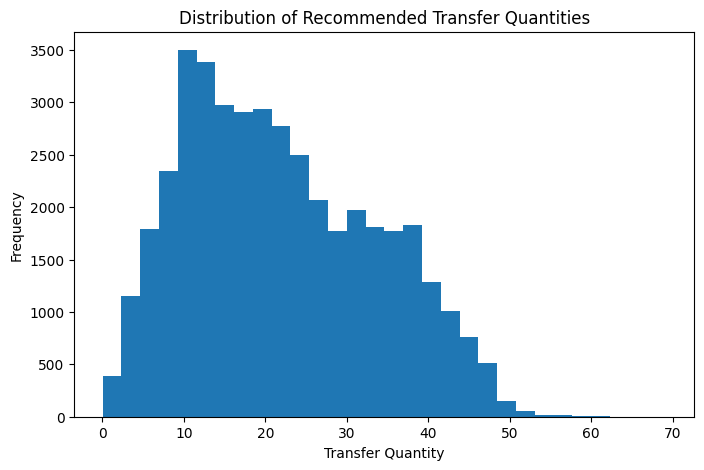

In [178]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
transfer_recommendations["transfer_qty"].plot(kind="hist", bins=30)
plt.title("Distribution of Recommended Transfer Quantities")
plt.xlabel("Transfer Quantity")
plt.ylabel("Frequency")
plt.show()

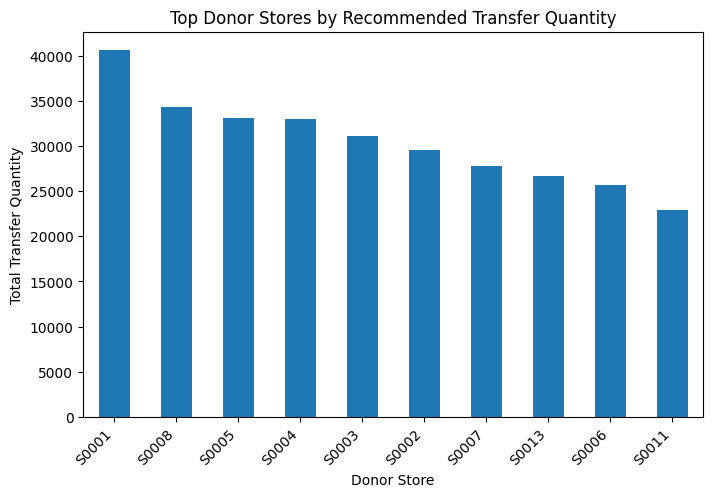

In [179]:
top_donors = (
    transfer_recommendations.groupby("donor_store_id")["transfer_qty"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
top_donors.plot(kind="bar")
plt.title("Top Donor Stores by Recommended Transfer Quantity")
plt.xlabel("Donor Store")
plt.ylabel("Total Transfer Quantity")
plt.xticks(rotation=45, ha="right")
plt.show()

In [180]:
# Add region info from original state table
transfer_df = transfer_df.merge(
    state[["store_id", "sku_id", "date", "region"]],
    on=["store_id", "sku_id", "date"],
    how="left"
)

In [181]:
# Assumptions (you can tune these)
INTRA_REGION_TRANSFER_DAYS = 1
INTER_REGION_TRANSFER_DAYS = 3

In [182]:
donors = transfer_df[transfer_df["donor_flag"] == 1].copy()
receivers = transfer_df[transfer_df["receiver_flag"] == 1].copy()

donors = donors.rename(columns={
    "store_id": "donor_store",
    "region": "donor_region",
    "donor_excess_stock": "donor_excess"
})

receivers = receivers.rename(columns={
    "store_id": "receiver_store",
    "region": "receiver_region",
    "receiver_required_stock": "receiver_need"
})

In [183]:
matches = donors.merge(
    receivers,
    on=["sku_id", "date"],
    how="inner"
)

# avoid same store
matches = matches[matches["donor_store"] != matches["receiver_store"]]

In [184]:
def decide_transfer(row):
    supplier_time = row["lead_time_days_avg_y"]  # from receiver side

    # SAME REGION
    if row["donor_region"] == row["receiver_region"]:
        if INTRA_REGION_TRANSFER_DAYS < supplier_time:
            return "Intra-region Transfer"
        else:
            return "Wait for Supplier"

    # DIFFERENT REGION
    else:
        if INTER_REGION_TRANSFER_DAYS < supplier_time:
            return "Inter-region Transfer"
        else:
            return "Wait for Supplier"

matches["transfer_decision"] = matches.apply(decide_transfer, axis=1)

In [185]:
matches["transfer_qty"] = np.minimum(
    matches["donor_excess"],
    matches["receiver_need"]
)

matches = matches[matches["transfer_qty"] > 0]

In [186]:
transfer_recommendations = matches[
    matches["transfer_decision"] != "Wait for Supplier"
].copy()

transfer_recommendations = transfer_recommendations[[
    "date", "sku_id",
    "donor_store", "receiver_store",
    "donor_region", "receiver_region",
    "transfer_qty", "transfer_decision"
]]

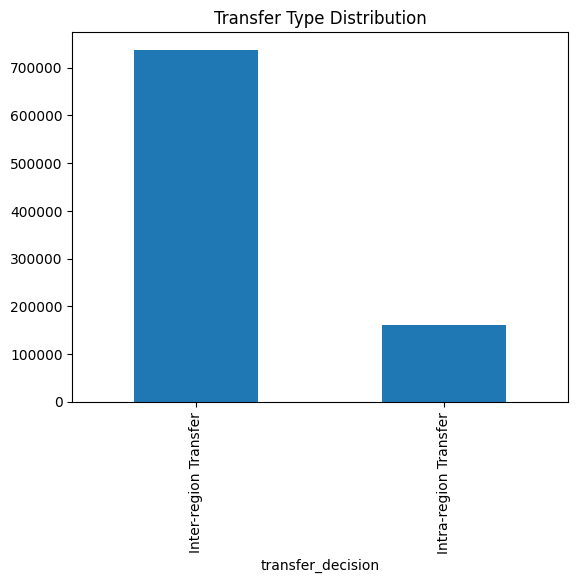

In [187]:
transfer_recommendations["transfer_decision"].value_counts().plot(kind="bar")
plt.title("Transfer Type Distribution")
plt.show()

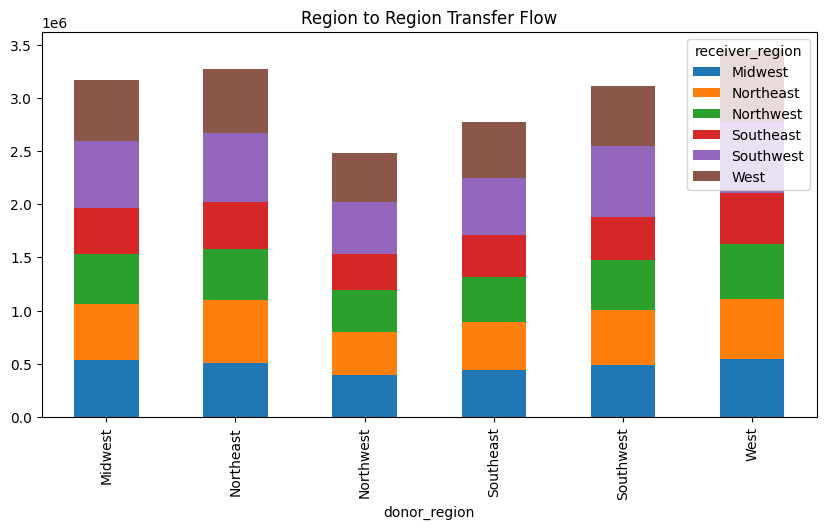

In [188]:
flow = transfer_recommendations.groupby(
    ["donor_region", "receiver_region"]
)["transfer_qty"].sum().unstack()

flow.plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Region to Region Transfer Flow")
plt.show()

In [189]:
region_sku_df = (
    allocation_df.groupby(["sku_id", "product_name", "region"], as_index=False)
    .agg(
        avg_daily_sales=("avg_daily_sales", "mean"),
        avg_stock=("total_avg_stock", "mean"),
        avg_reorder_point=("reorder_point", "mean"),
        avg_safety_stock=("safety_stock", "mean")
    )
)

region_sku_df["cover_days"] = (
    region_sku_df["avg_stock"] / (region_sku_df["avg_daily_sales"] + 1e-6)
)

region_sku_df.head()

,sku_id,product_name,region,avg_daily_sales,avg_stock,avg_reorder_point,avg_safety_stock,cover_days
0,P00001,QuickFresh Value Pack Energy Drinks 250g,Midwest,7.364456,138.935714,120.0,60.0,18.865711
1,P00001,QuickFresh Value Pack Energy Drinks 250g,Northeast,15.043852,140.400000,120.0,60.0,9.332715
2,P00001,QuickFresh Value Pack Energy Drinks 250g,Northwest,12.567012,145.985714,120.0,60.0,11.616581
3,P00001,QuickFresh Value Pack Energy Drinks 250g,Southeast,12.528649,157.890476,120.0,60.0,12.602353
4,P00001,QuickFresh Value Pack Energy Drinks 250g,Southwest,11.910310,127.634014,120.0,60.0,10.716262


In [190]:
region_sku_df["stock_status"] = "Healthy"

region_sku_df.loc[region_sku_df["cover_days"] < 7, "stock_status"] = "Understock"
region_sku_df.loc[region_sku_df["cover_days"] > 21, "stock_status"] = "Overstock"

region_sku_df["stock_status"].value_counts()

stock_status
Overstock     4146
Healthy       2514
Understock     876
Name: count, dtype: int64

In [191]:
donor_regions = region_sku_df[region_sku_df["stock_status"] == "Overstock"].copy()
receiver_regions = region_sku_df[region_sku_df["stock_status"] == "Understock"].copy()

print("Donors:", donor_regions.shape)
print("Receivers:", receiver_regions.shape)

Donors: (4146, 9)
Receivers: (876, 9)


In [192]:
region_matches = donor_regions.merge(
    receiver_regions,
    on=["sku_id", "product_name"],
    how="inner",
    suffixes=("_donor", "_receiver")
)

region_matches = region_matches[
    region_matches["region_donor"] != region_matches["region_receiver"]
].copy()

region_matches.head()

,sku_id,product_name,region_donor,avg_daily_sales_donor,avg_stock_donor,avg_reorder_point_donor,avg_safety_stock_donor,cover_days_donor,stock_status_donor,region_receiver,avg_daily_sales_receiver,avg_stock_receiver,avg_reorder_point_receiver,avg_safety_stock_receiver,cover_days_receiver,stock_status_receiver
0,P00106,TrueGrain Crispy Juices 1L,Midwest,2.903704,92.019048,78.0,39.0,31.690222,Overstock,West,12.492267,84.160000,78.0,39.0,6.736967,Understock
1,P00146,GoldenLeaf Deluxe Juices 500ml,Southwest,4.615534,111.316190,87.0,44.0,24.117721,Overstock,Northwest,16.272998,95.936508,87.0,44.0,5.895441,Understock
2,P00201,SunValley Family Size Milk 250g,Midwest,5.007558,129.904762,107.0,54.0,25.941734,Overstock,Southeast,18.121417,108.819048,107.0,54.0,6.004996,Understock
3,P00201,SunValley Family Size Milk 250g,Northeast,3.082215,128.057143,107.0,54.0,41.547096,Overstock,Southeast,18.121417,108.819048,107.0,54.0,6.004996,Understock
4,P00201,SunValley Family Size Milk 250g,Northwest,5.307198,136.278095,107.0,54.0,25.677967,Overstock,Southeast,18.121417,108.819048,107.0,54.0,6.004996,Understock


In [193]:
region_matches["donor_excess_units"] = (
    region_matches["avg_stock_donor"] - 21 * region_matches["avg_daily_sales_donor"]
).clip(lower=0)

region_matches["receiver_needed_units"] = (
    7 * region_matches["avg_daily_sales_receiver"] - region_matches["avg_stock_receiver"]
).clip(lower=0)

region_matches["transfer_qty"] = np.minimum(
    region_matches["donor_excess_units"],
    region_matches["receiver_needed_units"]
)

region_matches = region_matches[
    region_matches["transfer_qty"] > 0
].copy()

In [194]:
def final_decision(row):
    if row["transfer_qty"] > 0:
        return "Transfer Recommended"
    return "Adjust Replenishment"

region_matches["final_action"] = region_matches.apply(final_decision, axis=1)

In [195]:
planning_df = region_sku_df.copy()

planning_df["replenishment_action"] = "Maintain"

planning_df.loc[
    (planning_df["stock_status"] == "Overstock") &
    (planning_df["avg_daily_sales"] < planning_df["avg_daily_sales"].median()),
    "replenishment_action"
] = "Reduce Replenishment"

planning_df.loc[
    (planning_df["stock_status"] == "Understock") &
    (planning_df["avg_daily_sales"] > planning_df["avg_daily_sales"].median()),
    "replenishment_action"
] = "Increase Replenishment"

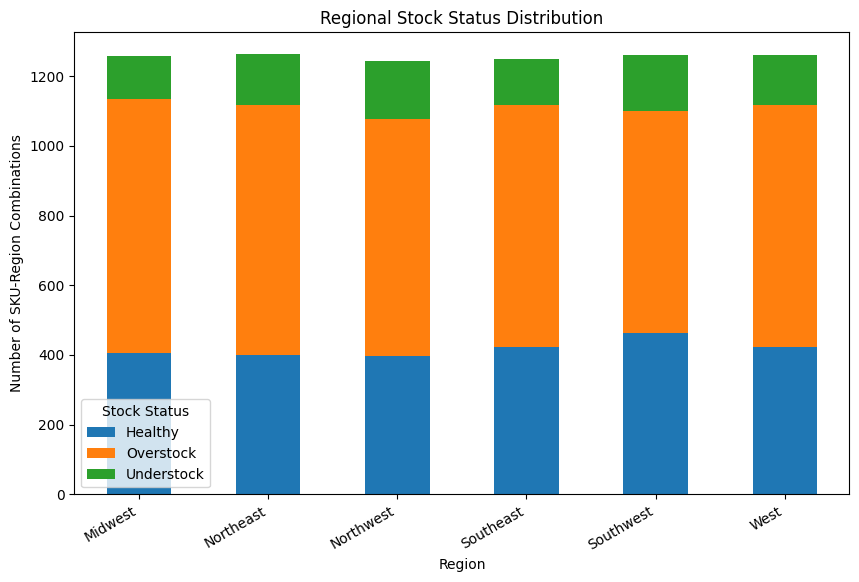

In [196]:
import matplotlib.pyplot as plt
import pandas as pd

region_status_counts = (
    region_sku_df.groupby(["region", "stock_status"])
    .size()
    .unstack(fill_value=0)
)

region_status_counts.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Regional Stock Status Distribution")
plt.xlabel("Region")
plt.ylabel("Number of SKU-Region Combinations")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Stock Status")
plt.show()

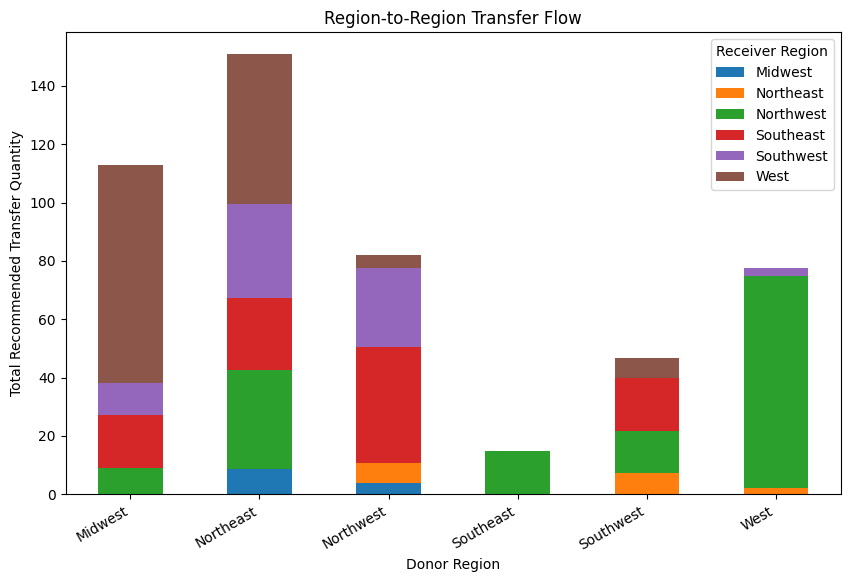

In [197]:
transfer_flow = (
    region_matches.groupby(["region_donor", "region_receiver"])["transfer_qty"]
    .sum()
    .unstack(fill_value=0)
)

transfer_flow.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Region-to-Region Transfer Flow")
plt.xlabel("Donor Region")
plt.ylabel("Total Recommended Transfer Quantity")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Receiver Region")
plt.show()

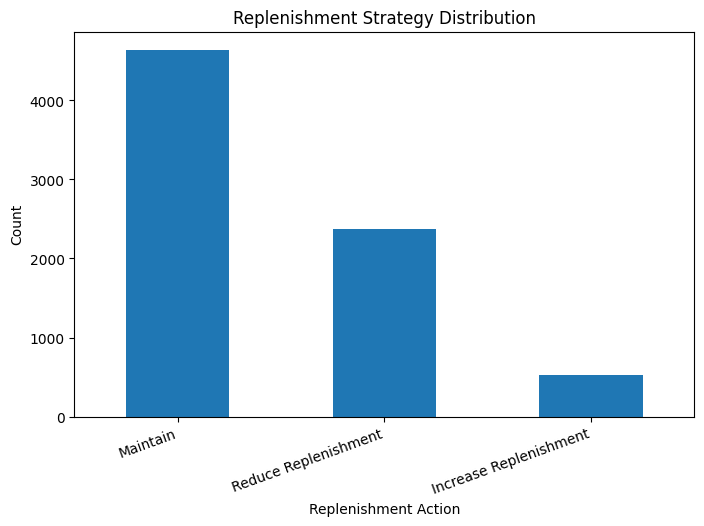

In [198]:
planning_df["replenishment_action"].value_counts().plot(
    kind="bar", figsize=(8, 5)
)
plt.title("Replenishment Strategy Distribution")
plt.xlabel("Replenishment Action")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.show()

In [199]:
print(region_sku_df.columns.tolist())

['sku_id', 'product_name', 'region', 'avg_daily_sales', 'avg_stock', 'avg_reorder_point', 'avg_safety_stock', 'cover_days', 'stock_status']


In [200]:
product_region_table = region_sku_df.pivot_table(
    index=["sku_id", "product_name"],
    columns="region",
    values="stock_status",
    aggfunc="first"
).reset_index()

In [201]:
all_regions = ["Midwest", "Northeast", "Northwest", "Southeast", "Southwest", "West"]

for r in all_regions:
    if r not in product_region_table.columns:
        product_region_table[r] = "No Data"

product_region_table = product_region_table[["sku_id", "product_name"] + all_regions]

In [202]:
product_region_table.head(20)

region,sku_id,product_name,Midwest,Northeast,Northwest,Southeast,Southwest,West
0,P00001,QuickFresh Value Pack Energy Drinks 250g,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy
1,P00002,SimplySmart Extra Fresh Water 500ml,Overstock,Healthy,Healthy,Overstock,Healthy,Healthy
2,P00003,NaturePath Pure Juices 6-Pack,Overstock,Healthy,Healthy,Healthy,Healthy,Healthy
3,P00004,DailyEssentials Smooth Coffee & Tea 500ml,Overstock,Overstock,Overstock,Overstock,Overstock,Overstock
4,P00005,HomeLine Ultra Water 150g,Overstock,Overstock,Healthy,Overstock,Healthy,Healthy
5,P00006,HomeLine Organic Water 1kg,Overstock,Overstock,Overstock,Overstock,Overstock,Overstock
6,P00007,DailyEssentials Lite Water 250g,Healthy,Understock,Understock,Understock,Healthy,Understock
7,P00008,GoldenLeaf Family Size Coffee & Tea 500ml,Healthy,Healthy,Healthy,Healthy,Healthy,Overstock
8,P00009,QuickFresh Deluxe Sodas 250g,Overstock,Overstock,Overstock,Overstock,Overstock,Overstock
9,P00010,PureStart Premium Juices 150g,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy


In [203]:
def overall_product_status(row):
    statuses = row[all_regions].values
    
    if ("Overstock" in statuses or "Overstocked" in statuses) and ("Understock" in statuses or "Understocked" in statuses):
        return "Rebalance Across Regions"
    elif "Overstock" in statuses or "Overstocked" in statuses:
        return "Reduce Replenishment"
    elif "Understock" in statuses or "Understocked" in statuses:
        return "Increase Replenishment"
    else:
        return "Healthy"

product_region_table["overall_action"] = product_region_table.apply(overall_product_status, axis=1)

In [204]:
product_region_table.head(20)

region,sku_id,product_name,Midwest,Northeast,Northwest,Southeast,Southwest,West,overall_action
0,P00001,QuickFresh Value Pack Energy Drinks 250g,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy
1,P00002,SimplySmart Extra Fresh Water 500ml,Overstock,Healthy,Healthy,Overstock,Healthy,Healthy,Reduce Replenishment
2,P00003,NaturePath Pure Juices 6-Pack,Overstock,Healthy,Healthy,Healthy,Healthy,Healthy,Reduce Replenishment
3,P00004,DailyEssentials Smooth Coffee & Tea 500ml,Overstock,Overstock,Overstock,Overstock,Overstock,Overstock,Reduce Replenishment
4,P00005,HomeLine Ultra Water 150g,Overstock,Overstock,Healthy,Overstock,Healthy,Healthy,Reduce Replenishment
5,P00006,HomeLine Organic Water 1kg,Overstock,Overstock,Overstock,Overstock,Overstock,Overstock,Reduce Replenishment
6,P00007,DailyEssentials Lite Water 250g,Healthy,Understock,Understock,Understock,Healthy,Understock,Increase Replenishment
7,P00008,GoldenLeaf Family Size Coffee & Tea 500ml,Healthy,Healthy,Healthy,Healthy,Healthy,Overstock,Reduce Replenishment
8,P00009,QuickFresh Deluxe Sodas 250g,Overstock,Overstock,Overstock,Overstock,Overstock,Overstock,Reduce Replenishment
9,P00010,PureStart Premium Juices 150g,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy


In [205]:
region_cols = ["Midwest", "Northeast", "Northwest", "Southeast", "Southwest", "West"]

def dynamic_overall_action(row):
    overstock_regions = [r for r in region_cols if row[r] == "Overstock"]
    understock_regions = [r for r in region_cols if row[r] == "Understock"]

    if overstock_regions and understock_regions:
        return (
            "Rebalance: reduce replenishment in "
            + ", ".join(overstock_regions)
            + " for 10-15 days; increase replenishment in "
            + ", ".join(understock_regions)
        )

    elif overstock_regions:
        return (
            "Reduce replenishment in "
            + ", ".join(overstock_regions)
            + " for 10-15 days"
        )

    elif understock_regions:
        return (
            "Increase replenishment in "
            + ", ".join(understock_regions)
            + " for next cycle"
        )

    else:
        return "Maintain current replenishment"

product_region_table["overall_action"] = product_region_table.apply(dynamic_overall_action, axis=1)

product_region_table.head(20)

region,sku_id,product_name,Midwest,Northeast,Northwest,Southeast,Southwest,West,overall_action
0,P00001,QuickFresh Value Pack Energy Drinks 250g,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Maintain current replenishment
1,P00002,SimplySmart Extra Fresh Water 500ml,Overstock,Healthy,Healthy,Overstock,Healthy,Healthy,"Reduce replenishment in Midwest, Southeast for..."
2,P00003,NaturePath Pure Juices 6-Pack,Overstock,Healthy,Healthy,Healthy,Healthy,Healthy,Reduce replenishment in Midwest for 10-15 days
3,P00004,DailyEssentials Smooth Coffee & Tea 500ml,Overstock,Overstock,Overstock,Overstock,Overstock,Overstock,"Reduce replenishment in Midwest, Northeast, No..."
4,P00005,HomeLine Ultra Water 150g,Overstock,Overstock,Healthy,Overstock,Healthy,Healthy,"Reduce replenishment in Midwest, Northeast, So..."
5,P00006,HomeLine Organic Water 1kg,Overstock,Overstock,Overstock,Overstock,Overstock,Overstock,"Reduce replenishment in Midwest, Northeast, No..."
6,P00007,DailyEssentials Lite Water 250g,Healthy,Understock,Understock,Understock,Healthy,Understock,"Increase replenishment in Northeast, Northwest..."
7,P00008,GoldenLeaf Family Size Coffee & Tea 500ml,Healthy,Healthy,Healthy,Healthy,Healthy,Overstock,Reduce replenishment in West for 10-15 days
8,P00009,QuickFresh Deluxe Sodas 250g,Overstock,Overstock,Overstock,Overstock,Overstock,Overstock,"Reduce replenishment in Midwest, Northeast, No..."
9,P00010,PureStart Premium Juices 150g,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Maintain current replenishment


In [206]:
region_cols = ["Midwest", "Northeast", "Northwest", "Southeast", "Southwest", "West"]

# Fix balance type
product_region_table["balance_type"] = product_region_table[region_cols].apply(
    lambda row: "Balanced" if all(status == "Healthy" for status in row) else "Unbalanced",
    axis=1
)

# Fix imbalance region count
product_region_table["imbalance_regions"] = product_region_table[region_cols].apply(
    lambda row: sum(status != "Healthy" for status in row),
    axis=1
)

product_region_table.head(20)

region,sku_id,product_name,Midwest,Northeast,Northwest,Southeast,Southwest,West,overall_action,balance_type,imbalance_regions
0,P00001,QuickFresh Value Pack Energy Drinks 250g,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Maintain current replenishment,Balanced,0
1,P00002,SimplySmart Extra Fresh Water 500ml,Overstock,Healthy,Healthy,Overstock,Healthy,Healthy,"Reduce replenishment in Midwest, Southeast for...",Unbalanced,2
2,P00003,NaturePath Pure Juices 6-Pack,Overstock,Healthy,Healthy,Healthy,Healthy,Healthy,Reduce replenishment in Midwest for 10-15 days,Unbalanced,1
3,P00004,DailyEssentials Smooth Coffee & Tea 500ml,Overstock,Overstock,Overstock,Overstock,Overstock,Overstock,"Reduce replenishment in Midwest, Northeast, No...",Unbalanced,6
4,P00005,HomeLine Ultra Water 150g,Overstock,Overstock,Healthy,Overstock,Healthy,Healthy,"Reduce replenishment in Midwest, Northeast, So...",Unbalanced,3
5,P00006,HomeLine Organic Water 1kg,Overstock,Overstock,Overstock,Overstock,Overstock,Overstock,"Reduce replenishment in Midwest, Northeast, No...",Unbalanced,6
6,P00007,DailyEssentials Lite Water 250g,Healthy,Understock,Understock,Understock,Healthy,Understock,"Increase replenishment in Northeast, Northwest...",Unbalanced,4
7,P00008,GoldenLeaf Family Size Coffee & Tea 500ml,Healthy,Healthy,Healthy,Healthy,Healthy,Overstock,Reduce replenishment in West for 10-15 days,Unbalanced,1
8,P00009,QuickFresh Deluxe Sodas 250g,Overstock,Overstock,Overstock,Overstock,Overstock,Overstock,"Reduce replenishment in Midwest, Northeast, No...",Unbalanced,6
9,P00010,PureStart Premium Juices 150g,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Maintain current replenishment,Balanced,0


In [207]:
def product_balance_type(row):
    values = row[["Midwest", "Northeast", "Northwest", "Southeast", "Southwest", "West"]].values
    
    if all(v == "Balanced" for v in values):
        return "Fully Balanced"
    else:
        return "Unbalanced"

product_region_table["balance_type"] = product_region_table.apply(product_balance_type, axis=1)

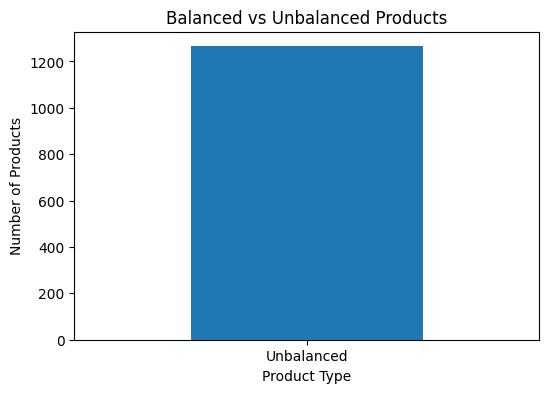

In [208]:
import matplotlib.pyplot as plt

product_region_table["balance_type"].value_counts().plot(kind="bar", figsize=(6,4))

plt.title("Balanced vs Unbalanced Products")
plt.xlabel("Product Type")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)

plt.show()

In [209]:
def imbalance_count(row):
    values = row[["Midwest", "Northeast", "Northwest", "Southeast", "Southwest", "West"]].values
    return sum(v != "Balanced" for v in values)

product_region_table["imbalance_regions"] = product_region_table.apply(imbalance_count, axis=1)

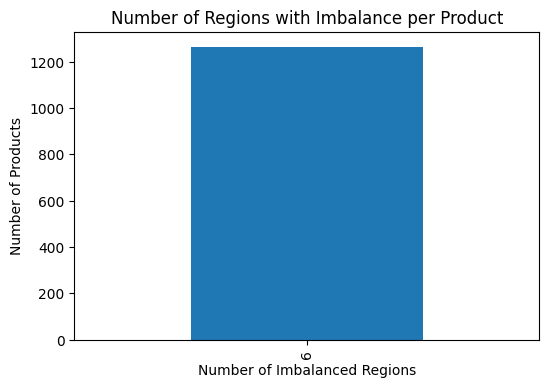

In [210]:
product_region_table["imbalance_regions"].value_counts().sort_index().plot(kind="bar", figsize=(6,4))

plt.title("Number of Regions with Imbalance per Product")
plt.xlabel("Number of Imbalanced Regions")
plt.ylabel("Number of Products")

plt.show()

In [211]:
region_cols = ["Midwest", "Northeast", "Northwest", "Southeast", "Southwest", "West"]

region_imbalance_counts = {}

for col in region_cols:
    region_imbalance_counts[col] = (product_region_table[col] != "Balanced").sum()

import pandas as pd
region_imbalance_df = pd.DataFrame.from_dict(region_imbalance_counts, orient='index', columns=['imbalance_count'])
region_imbalance_df = region_imbalance_df.sort_values(by="imbalance_count", ascending=False)

region_imbalance_df

,imbalance_count
Midwest,1265
Northeast,1265
Northwest,1265
Southeast,1265
Southwest,1265
West,1265


In [212]:
latest_date = df_eval["date"].max()
latest_df = df_eval[df_eval["date"] == latest_date].copy()

In [213]:
print(latest_date)

2025-12-22 00:00:00


In [214]:
print("Sales max date:", sales["sale_date"].max())
print("Inventory max date:", inventory["snapshot_date"].max())
print("Model/eval max date:", df_eval["date"].max())

Sales max date: 2025-12-31 00:00:00
Inventory max date: 2025-12-29 00:00:00
Model/eval max date: 2025-12-22 00:00:00


LOCALIZATION

In [215]:
latest_date = df_eval["date"].max()
print("Latest operational date:", latest_date)

latest_df = df_eval[df_eval["date"] == latest_date].copy()
print(latest_df.shape)

Latest operational date: 2025-12-22 00:00:00
(38240, 31)


In [216]:
latest_df = latest_df.merge(
    stores[["store_id", "region", "city", "state"]],
    on="store_id",
    how="left"
)

latest_df = latest_df.merge(
    products[["sku_id", "product_name", "category", "is_perishable"]],
    on="sku_id",
    how="left"
)

In [217]:
latest_df["predicted_sales_final"] = latest_df["predicted_sales"]

In [218]:
latest_df["extra_stock"] = (
    latest_df["total_stock"] 
    - latest_df["predicted_sales_final"]
    - latest_df["safety_stock"]
)

latest_df["shortage_qty"] = (
    latest_df["predicted_sales_final"]
    + latest_df["safety_stock"]
    - latest_df["total_stock"]
)

latest_df["stock_status"] = "Healthy"

latest_df.loc[latest_df["extra_stock"] > 0, "stock_status"] = "Overstock"
latest_df.loc[latest_df["shortage_qty"] > 0, "stock_status"] = "Understock"

latest_df["stock_status"].value_counts()

stock_status
Overstock     32724
Understock     5516
Name: count, dtype: int64

In [219]:
replenishment["receive_date"] = pd.to_datetime(replenishment["receive_date"])
latest_df["date"] = pd.to_datetime(latest_df["date"])

In [220]:
replenishment_future = replenishment.merge(
    latest_df[["store_id", "sku_id", "date"]],
    on=["store_id", "sku_id"],
    how="inner"
)

replenishment_future = replenishment_future[
    replenishment_future["receive_date"] >= replenishment_future["date"]
].copy()

In [221]:
next_replenishment = (
    replenishment_future
    .sort_values("receive_date")
    .groupby(["store_id", "sku_id"], as_index=False)
    .first()[["store_id", "sku_id", "receive_date"]]
)

In [222]:
latest_df = latest_df.merge(
    next_replenishment,
    on=["store_id", "sku_id"],
    how="left"
)

# 17. Intra-Region Store Transfer
Match overstocked stores to understocked stores within the same region and SKU when replenishment is not nearby.

In [223]:
REPLENISHMENT_NEARBY_DAYS = 3

latest_df["days_to_replenishment"] = (
    latest_df["receive_date"] - latest_df["date"]
).dt.days

# fallback if no replenishment planned
latest_df.loc[
    latest_df["days_to_replenishment"].isna(),
    "days_to_replenishment"
] = latest_df["lead_time_days_avg"]

latest_df["replenishment_nearby"] = (
    latest_df["days_to_replenishment"] <= REPLENISHMENT_NEARBY_DAYS
)

In [224]:
latest_df[[
    "store_id", "sku_id", "date",
    "receive_date", "days_to_replenishment",
    "replenishment_nearby"
]].head(20)

,store_id,sku_id,date,receive_date,days_to_replenishment,replenishment_nearby
0,S0001,P00055,2025-12-22,2025-12-26,4.0,False
1,S0001,P00078,2025-12-22,NaT,14.0,False
2,S0001,P00084,2025-12-22,NaT,4.0,False
3,S0001,P00096,2025-12-22,2025-12-23,1.0,True
4,S0001,P00103,2025-12-22,2025-12-26,4.0,False
5,S0001,P00106,2025-12-22,2025-12-30,8.0,False
6,S0001,P00113,2025-12-22,2025-12-23,1.0,True
7,S0001,P00155,2025-12-22,2025-12-24,2.0,True
8,S0001,P00164,2025-12-22,2025-12-22,0.0,True
9,S0001,P00192,2025-12-22,NaT,10.0,False


In [225]:
store_donors = latest_df[
    latest_df["stock_status"] == "Overstock"
].copy()

store_receivers = latest_df[
    (latest_df["stock_status"] == "Understock") &
    (latest_df["replenishment_nearby"] == False)
].copy()

print("Donors:", store_donors.shape)
print("Receivers:", store_receivers.shape)

Donors: (32724, 44)
Receivers: (2359, 44)


In [226]:
intra_region_matches = store_donors.merge(
    store_receivers,
    on=["sku_id", "region"],
    suffixes=("_donor", "_receiver")
)

intra_region_matches = intra_region_matches[
    intra_region_matches["store_id_donor"] != intra_region_matches["store_id_receiver"]
].copy()

print("Intra-region raw matches:", intra_region_matches.shape)

Intra-region raw matches: (8813, 86)


In [227]:
intra_region_matches["transfer_qty"] = np.minimum(
    intra_region_matches["extra_stock_donor"],
    intra_region_matches["shortage_qty_receiver"]
)

intra_region_transfers = intra_region_matches[
    intra_region_matches["transfer_qty"] > 0
].copy()

print("Final intra-region transfers:", intra_region_transfers.shape)

Final intra-region transfers: (8813, 87)


# 18. Inter-Region Transfer
Aggregate inventory to product-region level and recommend feasible region-to-region transfers.

In [228]:
intra_region_transfer_final = intra_region_transfers[[
    "date_donor",
    "sku_id",
    "product_name_donor",
    "region",
    "store_id_donor",
    "store_id_receiver",
    "total_stock_donor",
    "predicted_sales_final_donor",
    "extra_stock_donor",
    "total_stock_receiver",
    "predicted_sales_final_receiver",
    "shortage_qty_receiver",
    "days_to_replenishment_receiver",
    "transfer_qty"
]].copy()

intra_region_transfer_final = intra_region_transfer_final.rename(columns={
    "date_donor": "date",
    "product_name_donor": "product_name",
    "store_id_donor": "donor_store",
    "store_id_receiver": "receiver_store"
})

intra_region_transfer_final["transfer_type"] = "Intra-region Store Transfer"

intra_region_transfer_final.head(20)

,date,sku_id,product_name,region,donor_store,receiver_store,total_stock_donor,predicted_sales_final_donor,extra_stock_donor,total_stock_receiver,predicted_sales_final_receiver,shortage_qty_receiver,days_to_replenishment_receiver,transfer_qty,transfer_type
0,2025-12-22,P00055,ClearChoice Pure Sodas 12-Pack,Southwest,S0001,S0447,127,26.830580,27.169420,57,24.338135,40.338135,7.0,27.169420,Intra-region Store Transfer
1,2025-12-22,P00084,PureStart Light Sodas 12-Pack,Southwest,S0001,S0108,192,17.450361,138.549639,37,5.804893,4.804893,7.0,4.804893,Intra-region Store Transfer
2,2025-12-22,P00155,UrbanHarvest Classic Yogurt 1L,Southwest,S0001,S0157,146,20.917006,27.082994,0,23.562984,121.562984,5.0,27.082994,Intra-region Store Transfer
3,2025-12-22,P00465,FreshMoment Deluxe Muffins 24ct,Southwest,S0001,S0037,190,18.330116,47.669884,139,19.765980,4.765980,5.0,4.765980,Intra-region Store Transfer
4,2025-12-22,P00465,FreshMoment Deluxe Muffins 24ct,Southwest,S0001,S0065,190,18.330116,47.669884,136,23.685976,11.685976,4.0,11.685976,Intra-region Store Transfer
5,2025-12-22,P00465,FreshMoment Deluxe Muffins 24ct,Southwest,S0001,S0238,190,18.330116,47.669884,128,8.692732,4.692732,4.0,4.692732,Intra-region Store Transfer
6,2025-12-22,P00488,BlueRidge Family Size Cookies 1L,Southwest,S0001,S0041,66,5.742416,34.257584,22,14.441576,18.441576,8.0,18.441576,Intra-region Store Transfer
7,2025-12-22,P00514,CoastalFarms Deluxe Muffins 500ml,Southwest,S0001,S0312,466,7.566786,267.433214,105,22.289341,108.289341,9.0,108.289341,Intra-region Store Transfer
8,2025-12-22,P00579,EverFresh Crispy Waffles 150g,Southwest,S0001,S0375,98,8.427514,76.572486,0,5.184273,18.184273,6.0,18.184273,Intra-region Store Transfer
9,2025-12-22,P00583,QuickFresh Pure Ice Cream 24ct,Southwest,S0001,S0447,372,10.720608,245.279392,128,23.880348,11.880348,5.0,11.880348,Intra-region Store Transfer


In [229]:
print("Total recommended intra-region transfers:", len(intra_region_transfer_final))
print("Total units recommended for transfer:", intra_region_transfer_final["transfer_qty"].sum())

intra_region_transfer_final.groupby("region")["transfer_qty"].sum().sort_values(ascending=False)

Total recommended intra-region transfers: 8813
Total units recommended for transfer: 290673.39667776227


region
Southwest    66280.627086
West         57166.512831
Midwest      49848.078386
Northeast    47105.580469
Southeast    37167.546681
Northwest    33105.051224
Name: transfer_qty, dtype: float64

In [230]:
region_product_df = (
    latest_df.groupby(["region", "sku_id", "product_name"], as_index=False)
    .agg(
        total_region_stock=("total_stock", "sum"),
        total_region_predicted_sales=("predicted_sales_final", "sum"),
        total_region_safety_stock=("safety_stock", "sum"),
        avg_days_to_replenishment=("days_to_replenishment", "mean")
    )
)

region_product_df.head()

,region,sku_id,product_name,total_region_stock,total_region_predicted_sales,total_region_safety_stock,avg_days_to_replenishment
0,Midwest,P00001,QuickFresh Value Pack Energy Drinks 250g,417,24.807617,240,10.500000
1,Midwest,P00002,SimplySmart Extra Fresh Water 500ml,538,25.984781,285,6.000000
2,Midwest,P00003,NaturePath Pure Juices 6-Pack,729,31.759344,320,3.600000
3,Midwest,P00004,DailyEssentials Smooth Coffee & Tea 500ml,3815,32.970993,1380,14.000000
4,Midwest,P00005,HomeLine Ultra Water 150g,1557,26.768406,606,2.833333


In [231]:
region_product_df["region_extra_stock"] = (
    region_product_df["total_region_stock"]
    - region_product_df["total_region_predicted_sales"]
    - region_product_df["total_region_safety_stock"]
)

region_product_df["region_shortage_qty"] = (
    region_product_df["total_region_predicted_sales"]
    + region_product_df["total_region_safety_stock"]
    - region_product_df["total_region_stock"]
)

region_product_df["region_stock_status"] = "Healthy"

region_product_df.loc[
    region_product_df["region_extra_stock"] > 0,
    "region_stock_status"
] = "Overstock"

region_product_df.loc[
    region_product_df["region_shortage_qty"] > 0,
    "region_stock_status"
] = "Understock"

region_product_df["region_stock_status"].value_counts()

region_stock_status
Overstock     7205
Understock     331
Name: count, dtype: int64

In [232]:
region_donors = region_product_df[
    region_product_df["region_stock_status"] == "Overstock"
].copy()

region_receivers = region_product_df[
    (region_product_df["region_stock_status"] == "Understock") &
    (region_product_df["avg_days_to_replenishment"] > REPLENISHMENT_NEARBY_DAYS)
].copy()

print("Region donors:", region_donors.shape)
print("Region receivers:", region_receivers.shape)

Region donors: (7205, 10)
Region receivers: (242, 10)


In [233]:
region_matches = region_donors.merge(
    region_receivers,
    on="sku_id",
    suffixes=("_donor", "_receiver")
)

# Remove same-region matches
region_matches = region_matches[
    region_matches["region_donor"] != region_matches["region_receiver"]
].copy()

print("Region-level raw matches:", region_matches.shape)

Region-level raw matches: (1049, 19)


In [234]:
# Define feasible region pairs (example logic)
feasible_pairs = [
    ("Midwest", "Northeast"),
    ("Northeast", "Midwest"),
    ("Southeast", "Southwest"),
    ("Southwest", "Southeast"),
    ("West", "Northwest"),
    ("Northwest", "West")
]

region_matches["feasible_transfer"] = region_matches.apply(
    lambda x: (x["region_donor"], x["region_receiver"]) in feasible_pairs,
    axis=1
)

region_matches = region_matches[
    region_matches["feasible_transfer"]
].copy()

print("Feasible region matches:", region_matches.shape)

Feasible region matches: (213, 20)


In [235]:
region_matches["transfer_qty"] = np.minimum(
    region_matches["region_extra_stock_donor"],
    region_matches["region_shortage_qty_receiver"]
)

region_transfers = region_matches[
    region_matches["transfer_qty"] > 0
].copy()

print("Final region transfers:", region_transfers.shape)

Final region transfers: (213, 21)


In [236]:
region_transfer_final = region_transfers[[
    "sku_id",
    "product_name_donor",
    "region_donor",
    "region_receiver",
    "total_region_stock_donor",
    "total_region_predicted_sales_donor",
    "region_extra_stock_donor",
    "total_region_stock_receiver",
    "total_region_predicted_sales_receiver",
    "region_shortage_qty_receiver",
    "avg_days_to_replenishment_receiver",
    "transfer_qty"
]].copy()

region_transfer_final = region_transfer_final.rename(columns={
    "product_name_donor": "product_name"
})

region_transfer_final["transfer_type"] = "Inter-region Transfer"

region_transfer_final.head(20)

,sku_id,product_name,region_donor,region_receiver,total_region_stock_donor,total_region_predicted_sales_donor,region_extra_stock_donor,total_region_stock_receiver,total_region_predicted_sales_receiver,region_shortage_qty_receiver,avg_days_to_replenishment_receiver,transfer_qty,transfer_type
0,P00001,QuickFresh Value Pack Energy Drinks 250g,Midwest,Northeast,417,24.807617,152.192383,227,54.470123,67.470123,3.750000,67.470123,Inter-region Transfer
14,P00105,QuickFresh Crispy Water 12-Pack,Midwest,Northeast,552,54.442131,197.557869,185,35.683247,30.683247,5.333333,30.683247,Inter-region Transfer
17,P00110,SimplySmart Lite Energy Drinks 250g,Midwest,Northeast,130,23.131638,43.868362,170,65.752831,63.752831,4.250000,43.868362,Inter-region Transfer
20,P00146,GoldenLeaf Deluxe Juices 500ml,Midwest,Northeast,1202,86.420151,763.579849,76,17.874001,29.874001,7.000000,29.874001,Inter-region Transfer
22,P00148,BrightBasket Organic Water 150g,Midwest,Northeast,216,42.685276,54.314724,81,50.180607,37.180607,5.250000,37.180607,Inter-region Transfer
24,P00150,FreshMoment Extra Fresh Sodas 12-Pack,Midwest,Northeast,98,27.143162,16.856838,0,12.409805,30.409805,17.000000,16.856838,Inter-region Transfer
28,P00185,GoldenLeaf Family Size Eggs 6-Pack,Midwest,Northeast,110,13.922104,54.077896,56,42.954586,70.954586,5.750000,54.077896,Inter-region Transfer
38,P00244,PureStart Ultra Yogurt 12-Pack,Midwest,Northeast,380,28.748535,267.251465,212,79.004463,63.004463,4.857143,63.004463,Inter-region Transfer
39,P00248,HearthStone Original Yogurt 2L,Midwest,Northeast,584,18.428314,359.571686,454,61.027962,19.027962,3.500000,19.027962,Inter-region Transfer
42,P00269,DailyEssentials Lite Eggs 500g,Midwest,Northeast,442,32.794140,297.205860,56,30.834208,38.834208,4.750000,38.834208,Inter-region Transfer


Shelf space management store level for the last day 

# 19. Product-Region Replenishment Planning
Create a product-region matrix showing which products are healthy, overstocked, or understocked across regions and generate replenishment recommendations.

In [237]:
# -------------------------------
# Store-Level Shelf Space Reallocation
# -------------------------------

store_space_df = latest_df.copy()

# 1. Product-level gap logic inside each store
store_space_df["excess_units"] = (
    store_space_df["total_stock"]
    - store_space_df["predicted_sales_final"]
    - store_space_df["safety_stock"]
)

store_space_df["needed_units"] = (
    store_space_df["predicted_sales_final"]
    + store_space_df["safety_stock"]
    - store_space_df["total_stock"]
)

store_space_df["product_stock_status"] = "Healthy"

store_space_df.loc[
    store_space_df["excess_units"] > 0,
    "product_stock_status"
] = "Overstock"

store_space_df.loc[
    store_space_df["needed_units"] > 0,
    "product_stock_status"
] = "Understock"

# 20. Store Shelf-Space Optimization
Identify products within each store where shelf space should be reduced or increased based on excess stock and shortage quantities.

In [238]:
# -------------------------------
# Group by store and create shelf-space action
# -------------------------------

def store_space_action(group):
    overstocked = group[group["product_stock_status"] == "Overstock"]
    understocked = group[group["product_stock_status"] == "Understock"]

    reduce_products = (
        overstocked
        .sort_values("excess_units", ascending=False)
        .head(5)["product_name"]
        .tolist()
    )

    increase_products = (
        understocked
        .sort_values("needed_units", ascending=False)
        .head(5)["product_name"]
        .tolist()
    )

    total_excess = overstocked["excess_units"].sum()
    total_need = understocked["needed_units"].sum()

    if len(reduce_products) > 0 and len(increase_products) > 0:
        action = (
            "Reduce shelf space for: "
            + ", ".join(reduce_products)
            + " | Reassign space to: "
            + ", ".join(increase_products)
        )
    elif len(reduce_products) > 0:
        action = (
            "Reduce shelf space for: "
            + ", ".join(reduce_products)
            + " | No understocked product found in this store"
        )
    elif len(increase_products) > 0:
        action = (
            "Increase shelf space for: "
            + ", ".join(increase_products)
            + " | No overstocked product available to reduce"
        )
    else:
        action = "Shelf space is balanced"

    return pd.Series({
        "overstocked_product_count": len(overstocked),
        "understocked_product_count": len(understocked),
        "total_excess_units": total_excess,
        "total_needed_units": total_need,
        "products_to_reduce_space": ", ".join(reduce_products),
        "products_to_increase_space": ", ".join(increase_products),
        "shelf_space_recommendation": action
    })


store_shelf_space_reallocation = (
    store_space_df
    .groupby(["store_id", "region"], as_index=False)
    .apply(store_space_action)
    .reset_index(drop=True)
)

store_shelf_space_reallocation.head(20)

C:\Users\gowth\AppData\Local\Temp\ipykernel_21864\3304473460.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(store_space_action)


,store_id,region,overstocked_product_count,understocked_product_count,total_excess_units,total_needed_units,products_to_reduce_space,products_to_increase_space,shelf_space_recommendation
0,S0001,Southwest,68,12,11858.639047,737.907770,"DailyEssentials Natural Yogurt 500g, NovaBrand...","QuickFresh Classic Fruits 1L, CoastalFarms Smo...",Reduce shelf space for: DailyEssentials Natura...
1,S0002,Northwest,66,14,14379.343569,1028.261218,"ClearChoice Family Size Canned Beans 6-Pack, Q...","UrbanHarvest Original Frozen Vegs 500ml, Daily...",Reduce shelf space for: ClearChoice Family Siz...
2,S0003,Midwest,61,19,14231.889547,1115.050755,"EverFresh Extra Fresh Supplements 150g, PrimeP...","GoldenLeaf Natural Soap 6-Pack, SimplySmart Pr...",Reduce shelf space for: EverFresh Extra Fresh ...
3,S0004,Southeast,70,10,12008.944266,455.920022,"FreshMoment Ultra Eggs 1L, DailyEssentials Ult...","ClearChoice Pure Popcorn 2L, QuickFresh Classi...",Reduce shelf space for: FreshMoment Ultra Eggs...
4,S0005,Midwest,68,12,15897.368882,239.953346,"DailyEssentials Smooth Coffee & Tea 500ml, Hea...","GoldenLeaf Light Granola Bars 24ct, TrueGrain ...",Reduce shelf space for: DailyEssentials Smooth...
5,S0006,Southwest,65,15,11941.313222,659.258121,"NovaBrand Ultra Treats 1L, DailyEssentials Smo...","BrightBasket Deluxe Deli Meats 1L, ClearChoice...",Reduce shelf space for: NovaBrand Ultra Treats...
6,S0007,West,70,10,11846.411353,370.723952,"SunValley Smooth Energy Drinks 500g, SimplySma...","DailyEssentials Classic Toothpaste 150g, TrueG...",Reduce shelf space for: SunValley Smooth Energ...
7,S0008,Northeast,71,9,13845.454846,151.636358,"DailyEssentials Deluxe Juices 2L, SunValley Na...","HomeLine Pure Shampoo 2L, DailyEssentials Clas...",Reduce shelf space for: DailyEssentials Deluxe...
8,S0009,Southwest,71,9,17865.277943,296.299556,"NaturePath Pure Crackers 12-Pack, HearthStone ...","PureStart Value Pack Mushrooms 500ml, HomeLine...",Reduce shelf space for: NaturePath Pure Cracke...
9,S0010,Southwest,75,5,16947.692703,104.411771,"HearthStone Light Wipes 500ml, CoastalFarms Bo...","ClearChoice Crispy Cleaning 150g, HomeLine Pre...",Reduce shelf space for: HearthStone Light Wipe...


Average shelf gap rate

# 21. Historical Store-Level Average Health
Use base sales, inventory, and forecast tables to calculate long-term store inventory health.

In [239]:
# -------------------------------
# Historical store-level average from BASE TABLES
# -------------------------------

# 1. Daily average sales per store
sales["sale_date"] = pd.to_datetime(sales["sale_date"])

store_sales_avg = (
    sales.groupby("store_id", as_index=False)
    .agg(
        avg_daily_units_sold=("units_sold", "mean"),
        total_units_sold=("units_sold", "sum"),
        total_revenue=("revenue", "sum")
    )
)

# 2. Average inventory per store
inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"])

inventory["total_stock"] = (
    inventory["units_on_hand"] + inventory["units_in_backroom"]
)

store_inventory_avg = (
    inventory.groupby("store_id", as_index=False)
    .agg(
        avg_total_stock=("total_stock", "mean"),
        avg_units_on_hand=("units_on_hand", "mean"),
        avg_backroom_stock=("units_in_backroom", "mean"),
        avg_days_of_supply=("days_of_supply", "mean")
    )
)

# 3. Average forecast per store from forecast base table
forecast["forecast_date"] = pd.to_datetime(forecast["forecast_date"])

store_forecast_avg = (
    forecast.groupby("store_id", as_index=False)
    .agg(
        avg_forecast_units=("forecast_units", "mean")
    )
)

# 4. Merge all historical averages
store_historical_avg = (
    store_inventory_avg
    .merge(store_sales_avg, on="store_id", how="left")
    .merge(store_forecast_avg, on="store_id", how="left")
    .merge(stores[["store_id", "region", "city", "state", "store_format"]], on="store_id", how="left")
)

# 5. Fill missing values
store_historical_avg[["avg_daily_units_sold", "avg_forecast_units"]] = (
    store_historical_avg[["avg_daily_units_sold", "avg_forecast_units"]].fillna(0)
)

# 6. Historical stock-to-demand ratio
store_historical_avg["historical_cover_ratio"] = (
    store_historical_avg["avg_total_stock"] /
    (store_historical_avg["avg_forecast_units"] + 1e-6)
)

# 7. Classify store average status
store_historical_avg["historical_store_status"] = "Balanced"

store_historical_avg.loc[
    store_historical_avg["historical_cover_ratio"] > 1.20,
    "historical_store_status"
] = "Historically Overstocked"

store_historical_avg.loc[
    store_historical_avg["historical_cover_ratio"] < 0.80,
    "historical_store_status"
] = "Historically Understocked"

store_historical_avg.head(20)

,store_id,avg_total_stock,avg_units_on_hand,avg_backroom_stock,avg_days_of_supply,avg_daily_units_sold,total_units_sold,total_revenue,avg_forecast_units,region,city,state,store_format,historical_cover_ratio,historical_store_status
0,S0001,286.194524,198.925952,87.268571,28.797698,16.597304,916055,24803935.33,15.183575,Southwest,New York,NY,Convenience,18.848954,Historically Overstocked
1,S0002,316.829524,222.622143,94.207381,39.774279,15.005322,823312,21343017.03,13.676787,Northwest,Los Angeles,CA,Supermarket,23.165492,Historically Overstocked
2,S0003,317.069167,219.532738,97.536429,33.358207,15.239887,829187,22316231.48,13.746246,Midwest,Chicago,IL,Discount,23.065871,Historically Overstocked
3,S0004,297.511786,213.012738,84.499048,54.286158,13.167696,718390,17272768.03,11.905302,Southeast,Houston,TX,Supermarket,24.989855,Historically Overstocked
4,S0005,328.931190,234.650833,94.280357,115.436800,5.496237,290630,6921863.41,4.816391,Midwest,Phoenix,AZ,Supermarket,68.294110,Historically Overstocked
5,S0006,297.377500,212.947500,84.430000,23.279026,17.278827,958422,26352948.01,15.877991,Southwest,Philadelphia,PA,Convenience,18.728911,Historically Overstocked
6,S0007,287.975833,204.988452,82.987381,27.642789,16.364068,906913,22690507.36,15.034901,West,San Antonio,TX,Convenience,19.153822,Historically Overstocked
7,S0008,282.131429,204.177143,77.954286,70.788902,5.268923,282056,7124144.44,4.674904,Northeast,San Diego,CA,Hypermarket,60.350194,Historically Overstocked
8,S0009,377.211310,273.974643,103.236667,37.242745,12.966485,724632,19290354.57,11.984736,Southwest,Dallas,TX,Supermarket,31.474307,Historically Overstocked
9,S0010,373.253571,265.854643,107.398929,138.563030,5.291494,282751,6751001.03,4.690235,Southwest,San Jose,CA,Wholesale,79.580976,Historically Overstocked


In [240]:
!pip install streamlit

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: C:\Program Files\Python311\python.exe -m pip install --upgrade pip


In [241]:
import sys
print(sys.executable)

c:\Users\gowth\AppData\Local\Programs\Python\Python313\python.exe


In [242]:
import sys
!{sys.executable} -m pip install streamlit


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [243]:
import streamlit as st
print("Now it works")

Now it works


In [244]:
import os
os.makedirs("outputs", exist_ok=True)

inventory_model.to_csv("outputs/phantom_inventory_history.csv", index=False)
df_eval.to_csv("outputs/final_predictions_risks_actions.csv", index=False)
store_shelf_space_reallocation.to_csv("outputs/store_shelf_space_reallocation.csv", index=False)
intra_region_transfer_final.to_csv("outputs/intra_region_transfers.csv", index=False)
region_transfer_final.to_csv("outputs/inter_region_transfers.csv", index=False)
product_region_table.to_csv("outputs/product_region_table.csv", index=False)
model_comparison.to_csv("outputs/model_comparison.csv", index=False)

print("All dashboard output files saved.")

All dashboard output files saved.


In [245]:
latest_df.columns

Index(['store_id', 'sku_id', 'date', 'daily_units_sold', 'avg_sales_7d',
       'avg_sales_14d', 'sales_std_7d', 'total_stock', 'units_on_hand',
       'units_in_backroom', 'days_of_supply', 'cover_days_est', 'promo_active',
       'promo_discount', 'promo_lift_factor', 'lead_time_days_avg',
       'lead_time_days_std', 'reliability_score', 'reorder_point',
       'safety_stock', 'shelf_fill_ratio', 'backroom_ratio',
       'target_next_day_sales', 'predicted_sales', 'expected_stock',
       'stockout_risk', 'phantom_flag_rule', 'risk_category', 'action',
       'priority_score', 'cause_label', 'region', 'city', 'state',
       'product_name', 'category', 'is_perishable', 'predicted_sales_final',
       'extra_stock', 'shortage_qty', 'stock_status', 'receive_date',
       'days_to_replenishment', 'replenishment_nearby'],
      dtype='object')

In [246]:
# Check available columns first
print(stores.columns.tolist())
print(df_eval.columns.tolist())

['store_id', 'store_name', 'region', 'city', 'state', 'store_format', 'foot_traffic_tier', 'num_aisles', 'open_date', 'sq_footage']
['store_id', 'sku_id', 'date', 'daily_units_sold', 'avg_sales_7d', 'avg_sales_14d', 'sales_std_7d', 'total_stock', 'units_on_hand', 'units_in_backroom', 'days_of_supply', 'cover_days_est', 'promo_active', 'promo_discount', 'promo_lift_factor', 'lead_time_days_avg', 'lead_time_days_std', 'reliability_score', 'reorder_point', 'safety_stock', 'shelf_fill_ratio', 'backroom_ratio', 'target_next_day_sales', 'predicted_sales', 'expected_stock', 'stockout_risk', 'phantom_flag_rule', 'risk_category', 'action', 'priority_score', 'cause_label']


In [247]:
print(df_eval.columns.tolist())

['store_id', 'sku_id', 'date', 'daily_units_sold', 'avg_sales_7d', 'avg_sales_14d', 'sales_std_7d', 'total_stock', 'units_on_hand', 'units_in_backroom', 'days_of_supply', 'cover_days_est', 'promo_active', 'promo_discount', 'promo_lift_factor', 'lead_time_days_avg', 'lead_time_days_std', 'reliability_score', 'reorder_point', 'safety_stock', 'shelf_fill_ratio', 'backroom_ratio', 'target_next_day_sales', 'predicted_sales', 'expected_stock', 'stockout_risk', 'phantom_flag_rule', 'risk_category', 'action', 'priority_score', 'cause_label']
